# Previsão de Churn de Clientes — Telco Customer Churn

**Projeto de classificação binária (Churn: Sim/Não) seguindo um pipeline completo de
ciência de dados (12 fases): dados → EDA → pré-processamento → split → balanceamento →
escalonamento → modelos base → tuning → threshold → diagnóstico → interpretabilidade →
entregáveis.**

**Dataset:** [Telco Customer Churn (IBM/Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
— 7.043 clientes de uma operadora de telecomunicações, com dados demográficos, serviços
contratados e informações de cobrança.

## Enquadramento de negócio (premissas assumidas para este projeto de portfólio)

Como este é um projeto autoguiado sobre um dataset público (não há um cliente real para
entrevistar), assumo e documento explicitamente as premissas de negócio que orientam as
decisões técnicas abaixo — troque-as se seu contexto real for outro:

- **Objetivo:** identificar clientes com alta probabilidade de cancelar (`Churn = Yes`)
  a tempo de uma equipe de retenção agir (oferta, desconto, contato proativo).
- **Classe de interesse ("evento positivo"):** `Churn = Yes`.
- **Custo relativo de erro:** assumo que um **falso negativo** (deixar de identificar um
  cliente que vai cancelar) custa mais caro do que um **falso positivo** (contatar um
  cliente que não iria cancelar) — perder a receita recorrente de um cliente tende a
  custar mais do que o custo de uma ação de retenção (ex: desconto, ligação). Isso vai
  orientar a escolha do threshold de decisão na Fase 9, priorizando **recall** sem
  abandonar a precision.
- **Interpretabilidade:** moderada — o time de retenção precisa entender *por que* um
  cliente foi sinalizado, para agir de forma direcionada (não é um contexto regulado
  como crédito, mas explicabilidade ainda importa).
- **Probabilidades calibradas:** úteis, pois a ideia é também poder ranquear clientes por
  risco (não só uma decisão binária), então calibração será avaliada na Fase 10.

**Nota sobre bibliotecas:** o ambiente onde este notebook foi construído não tem
`imbalanced-learn`, `xgboost`, `lightgbm` ou `shap` instalados, então usamos apenas
`scikit-learn` (que já cobre `class_weight='balanced'`, um `GradientBoostingClassifier`
nativo, calibração, PDP e permutation importance) e uma reamostragem manual simples como
alternativa ao SMOTE. Se você tiver essas bibliotecas no seu ambiente, os comentários no
código indicam onde plugá-las.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.

## Fase 1 — Carregamento e Inspeção Inicial dos Dados

In [2]:
# Localização automática do CSV -- procura na pasta atual e na pasta do próprio notebook,
# para funcionar mesmo se o Jupyter for aberto com outra pasta como diretório de trabalho
# (comum no VS Code, por exemplo). Mantém o notebook robusto em qualquer computador.
import os

def _achar_csv(nome_arquivo="TelcoCustomerChurn.csv"):
    bases = [os.getcwd()]
    try:
        dh = globals().get("_dh")
        if dh:
            bases.append(str(dh[0]))
    except Exception:
        pass
    for base in bases:
        caminho = os.path.join(base, nome_arquivo)
        if os.path.exists(caminho):
            return caminho
    return nome_arquivo  # deixa o pandas levantar o erro, com uma mensagem clara de onde procurou

df = pd.read_csv(_achar_csv())
print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head(3)

Shape: 7043 linhas x 21 colunas

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
df.dtypes

,0
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


In [4]:
# Variável target: 'Churn' (categórica binária: Yes/No)
print("Classes do target (Churn):", df["Churn"].unique())
print()
df.info()

Classes do target (Churn): <StringArray>
['No', 'Yes']
Length: 2, dtype: str

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043

In [5]:
print(f"Duplicatas completas: {df.duplicated().sum()}")
print(f"customerID duplicados: {df['customerID'].duplicated().sum()}")

Duplicatas completas: 0
customerID duplicados: 0

**Confirmação da Fase 1:** o problema é de classificação **binária** (`Churn`: Yes/No),
sem duplicatas de linha ou de `customerID`. `TotalCharges` está tipado como `object`
(texto) em vez de numérico — isso já é um sinal para investigar na EDA (Fase 2.4), pois
provavelmente há valores em branco ou mal formatados impedindo a conversão automática do
pandas.

## Fase 2 — Análise Exploratória (EDA) Detalhada

### 2.1 Análise do Target (distribuição de classes)

In [6]:
contagem = df["Churn"].value_counts()
percentual = df["Churn"].value_counts(normalize=True) * 100
resumo_target = pd.DataFrame({"contagem": contagem, "percentual_%": percentual.round(2)})
resumo_target

,contagem,percentual_%
Churn,,
No,5174,73.46
Yes,1869,26.54


Razão majoritária:minoritária = 2.77 : 1
Classificação de severidade: leve (< 3:1)

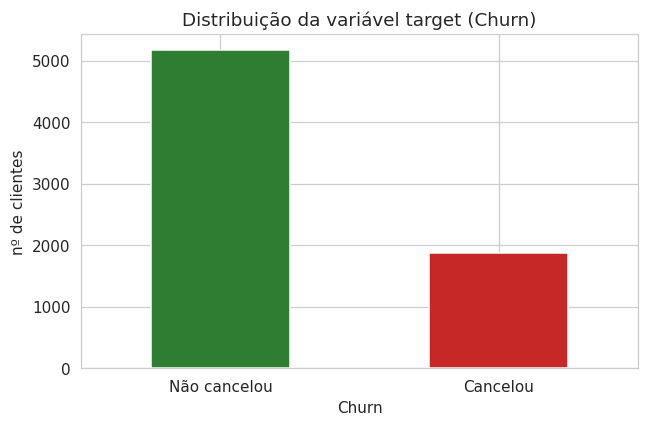

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#2e7d32", "#c62828"], ax=ax)
ax.set_title("Distribuição da variável target (Churn)")
ax.set_ylabel("nº de clientes")
ax.set_xticklabels(["Não cancelou", "Cancelou"], rotation=0)
plt.tight_layout()
plt.show()

razao_desbalanceamento = contagem.max() / contagem.min()
print(f"Razão majoritária:minoritária = {razao_desbalanceamento:.2f} : 1")
print("Classificação de severidade: leve (< 3:1)" if razao_desbalanceamento < 3
      else "moderado (3:1 a 10:1)" if razao_desbalanceamento < 10
      else "severo (> 10:1)")

**Leitura:** ~26,5% dos clientes cancelaram (`Churn = Yes`) — desbalanceamento **leve**
(razão ~2,77:1, abaixo do limiar de 3:1). Nenhuma classe tem menos de 30 amostras, então a
modelagem é totalmente viável. Não é um desbalanceamento extremo como fraude (tipicamente
>50:1) — então técnicas agressivas de reamostragem não são estritamente necessárias, mas
vamos comparar `class_weight='balanced'` vs. oversampling mesmo assim (Fase 5), para
documentar o processo e confirmar qual funciona melhor neste caso específico.

### 2.2 Análise de Variáveis Numéricas

In [8]:
# TotalCharges está como texto (object) -- converter para numérico
df["TotalCharges_numeric"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_nulos_totalcharges = df["TotalCharges_numeric"].isnull().sum()
print(f"Valores não conversíveis em TotalCharges (viram NaN): {n_nulos_totalcharges}")

features_numericas = ["tenure", "MonthlyCharges", "TotalCharges_numeric"]
df[features_numericas].describe()

Valores não conversíveis em TotalCharges (viram NaN): 11

,tenure,MonthlyCharges,TotalCharges_numeric
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


Assimetria (skew):
tenure                  0.24
MonthlyCharges         -0.22
TotalCharges_numeric    0.96
dtype: float64

Variância de cada feature (nenhuma deveria ser ~0):
tenure                      603.17
MonthlyCharges              905.41
TotalCharges_numeric    5138252.41
dtype: float64

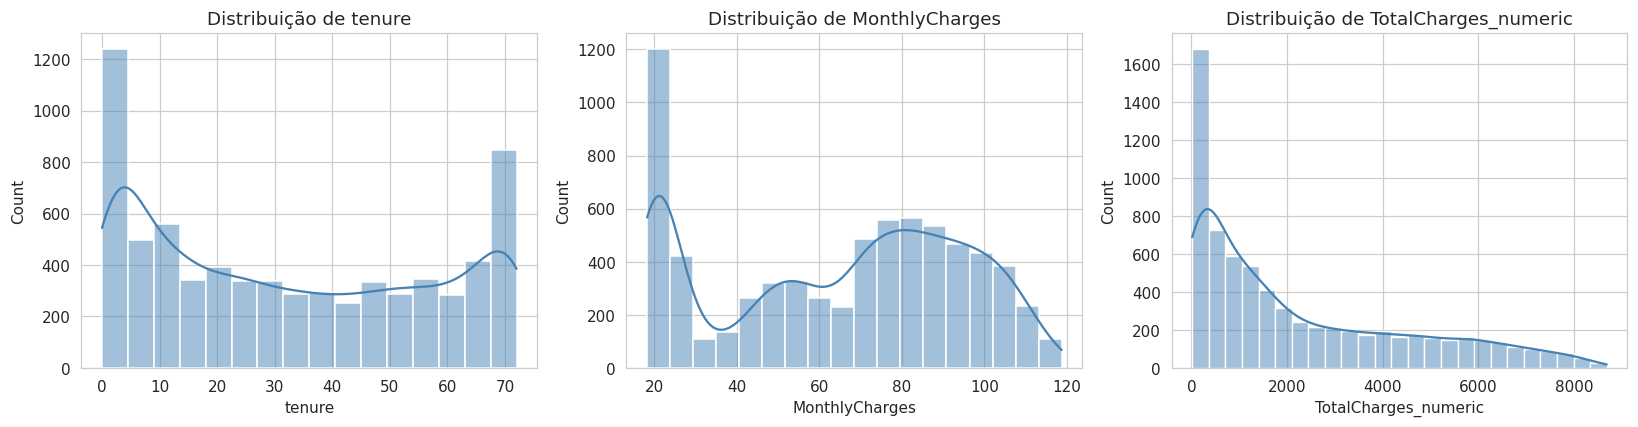

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, features_numericas):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()

print("Assimetria (skew):")
print(df[features_numericas].skew().round(2))

print()
variancia_quase_zero = df[features_numericas].var()
print("Variância de cada feature (nenhuma deveria ser ~0):")
print(variancia_quase_zero.round(2))

**Leitura:** nenhuma feature numérica tem variância zero/quase-zero (todas carregam
informação). `tenure` e `TotalCharges` têm leve assimetria à direita (mais clientes novos
do que antigos, e a maioria com total acumulado baixo) — esperado para dados de
assinatura, não indica erro. Nenhum valor fora do range possível pelo domínio (tenure
0–72 meses, cobranças positivas).

### 2.3 Análise de Variáveis Categóricas

In [10]:
features_categoricas = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
]

cardinalidade = df[features_categoricas].nunique().sort_values(ascending=False)
cardinalidade

,0
PaymentMethod,4
InternetService,3
MultipleLines,3
OnlineSecurity,3
DeviceProtection,3
TechSupport,3
OnlineBackup,3
StreamingTV,3
Contract,3
StreamingMovies,3


Nenhuma coluna categórica tem alta cardinalidade (todas com poucas categorias) — não
precisamos de Target/WOE Encoding, One-Hot Encoding simples já resolve. Não há
inconsistências de maiúsculas/minúsculas ou espaços (dataset já vem limpo nesse aspecto).

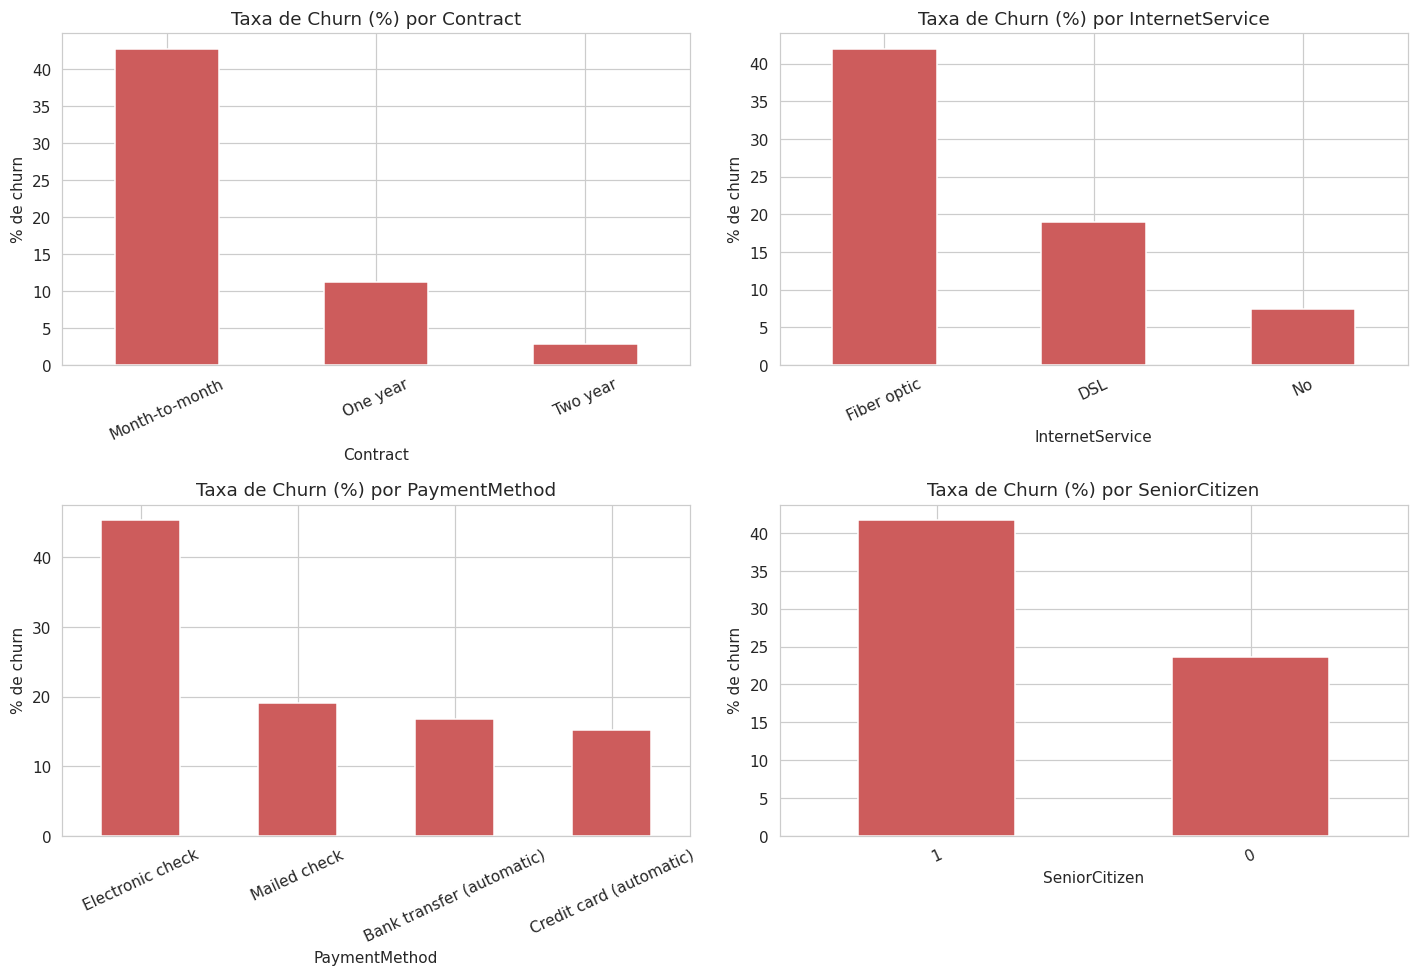

In [11]:
# Taxa de churn por categoria, para as variáveis mais relevantes ao negócio
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
principais = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]
for ax, col in zip(axes.flat, principais):
    taxa = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
    taxa.plot(kind="bar", ax=ax, color="indianred")
    ax.set_title(f"Taxa de Churn (%) por {col}")
    ax.set_ylabel("% de churn")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

**Leitura:** contratos `Month-to-month` têm taxa de churn muito mais alta do que `One
year`/`Two year` — sinal forte e esperado (sem fidelização, é mais fácil cancelar).
Clientes com `Fiber optic` cancelam mais do que `DSL` (possivelmente insatisfação com
preço/qualidade do serviço de fibra). Pagamento via `Electronic check` tem churn bem
acima dos demais métodos. Clientes `SeniorCitizen` (idosos) cancelam proporcionalmente
mais. Essas quatro variáveis já se destacam como fortes candidatas a features
importantes — vamos confirmar isso formalmente na seção 2.7 e na interpretabilidade
(Fase 11).

### 2.4 Análise de Nulos

In [12]:
nulos_por_coluna = df.isnull().sum()
print("Nulos originais (antes da conversão de TotalCharges):")
print(nulos_por_coluna[nulos_por_coluna > 0] if nulos_por_coluna.sum() > 0 else "Nenhum nulo nas colunas originais.")
print()
print(f"Nulos em TotalCharges_numeric (após conversão): {df['TotalCharges_numeric'].isnull().sum()}")

linhas_nulas = df[df["TotalCharges_numeric"].isnull()]
linhas_nulas[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Nulos originais (antes da conversão de TotalCharges):
TotalCharges_numeric    11
dtype: int64

Nulos em TotalCharges_numeric (após conversão): 11

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Achado de qualidade de dados:** as 11 linhas com `TotalCharges` em branco são **todas**
clientes com `tenure = 0` (acabaram de entrar, ainda não fecharam um ciclo de cobrança) —
não é um padrão aleatório (MCAR), é sistemático e explicável (MNAR determinístico): o
valor está ausente porque, para esses clientes, ele ainda não existe. Por isso, a decisão
correta aqui **não é** imputar com média/mediana genérica — é preencher com **0**, que é
o valor real esperado para "total cobrado até agora" de quem ainda não foi cobrado uma
vez sequer. Nenhuma dessas linhas tem `Churn = Yes`, o que faz sentido (cliente
recém-chegado ainda não teve chance de cancelar).

### 2.5 Outliers

Contagem de outliers por IQR (1.5x):
  tenure: 0 outliers (limites: [-60.0, 124.0])
  MonthlyCharges: 0 outliers (limites: [-46.0, 171.4])
  TotalCharges_numeric: 0 outliers (limites: [-4688.5, 8884.7])

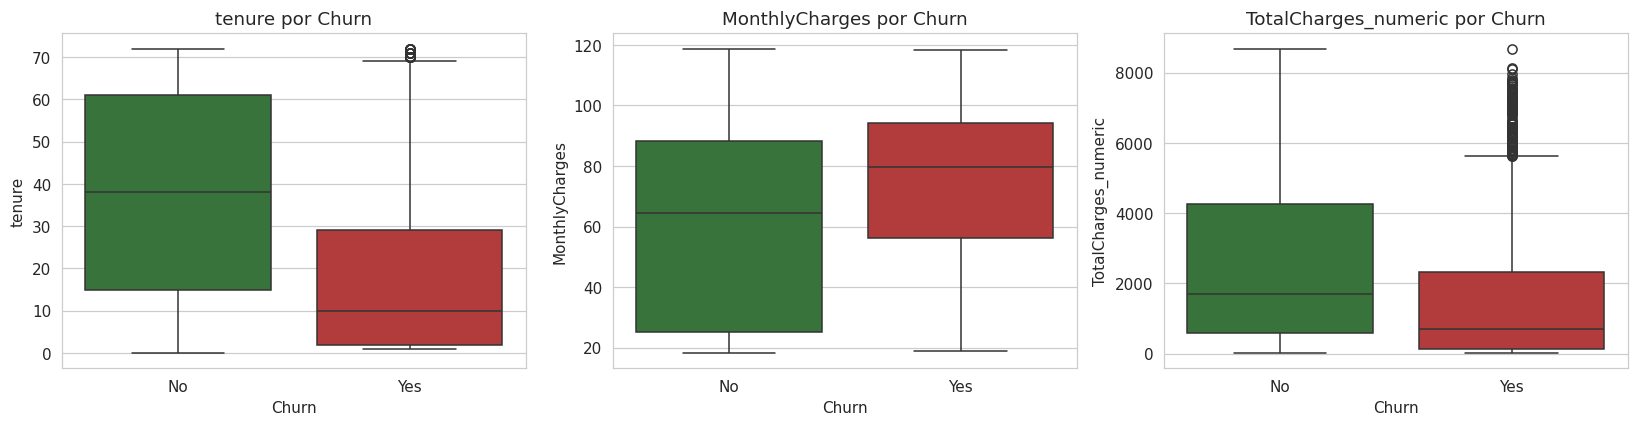

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, features_numericas):
    sns.boxplot(x=df["Churn"], y=df[col], ax=ax, palette=["#2e7d32", "#c62828"])
    ax.set_title(f"{col} por Churn")
plt.tight_layout()
plt.show()

print("Contagem de outliers por IQR (1.5x):")
for col in features_numericas:
    serie = df[col].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    print(f"  {col}: {n_outliers} outliers (limites: [{limite_inf:.1f}, {limite_sup:.1f}])")

**Leitura:** nenhuma das três variáveis numéricas tem outliers relevantes pela regra de
IQR — são todas grandezas naturalmente limitadas (meses de contrato, valores de cobrança
mensal/total dentro de faixas de plano), sem valores absurdos. Não é necessário
clipping/remoção nesta base.

### 2.6 Separabilidade entre Classes

Teste de Mann-Whitney U (a feature separa as duas classes?) e correlação point-biserial:
  tenure: p-valor Mann-Whitney = 2.42e-208 | correlação point-biserial = -0.352
  MonthlyCharges: p-valor Mann-Whitney = 3.31e-54 | correlação point-biserial = 0.193
  TotalCharges_numeric: p-valor Mann-Whitney = 2.00e-84 | correlação point-biserial = -0.199

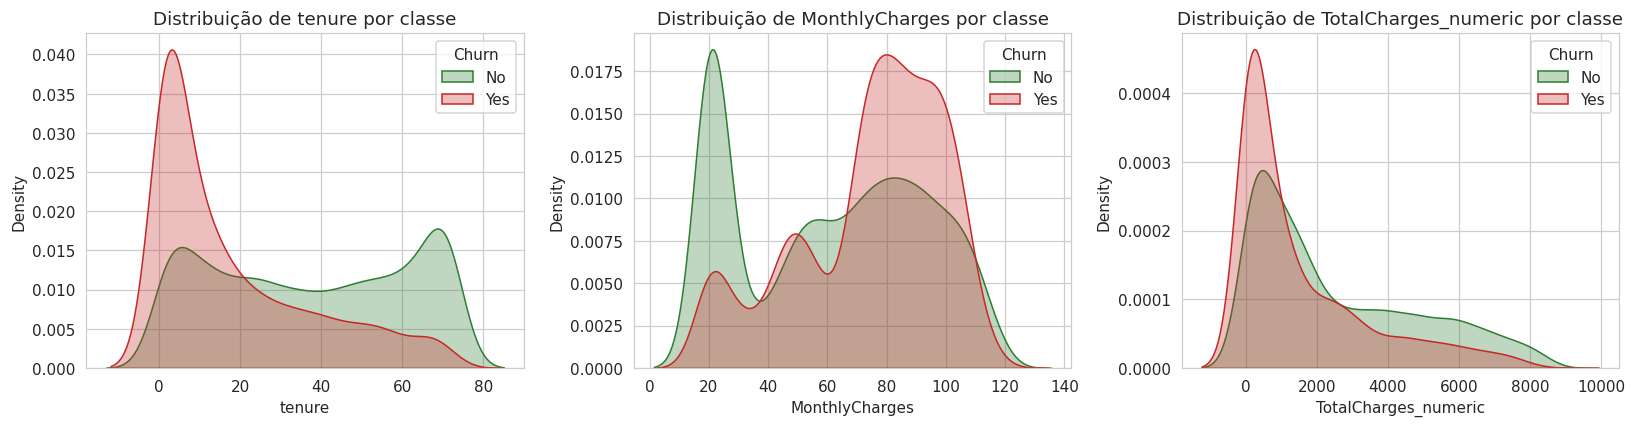

In [14]:
from scipy.stats import mannwhitneyu, pointbiserialr

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, features_numericas):
    for classe, cor in zip(["No", "Yes"], ["#2e7d32", "#c62828"]):
        sns.kdeplot(df.loc[df["Churn"] == classe, col].dropna(), ax=ax, label=classe, color=cor, fill=True, alpha=0.3)
    ax.set_title(f"Distribuição de {col} por classe")
    ax.legend(title="Churn")
plt.tight_layout()
plt.show()

print("Teste de Mann-Whitney U (a feature separa as duas classes?) e correlação point-biserial:")
for col in features_numericas:
    dados = df.dropna(subset=[col])
    grupo_no = dados.loc[dados["Churn"] == "No", col]
    grupo_yes = dados.loc[dados["Churn"] == "Yes", col]
    stat, p_valor = mannwhitneyu(grupo_no, grupo_yes)
    corr, _ = pointbiserialr((dados["Churn"] == "Yes").astype(int), dados[col])
    print(f"  {col}: p-valor Mann-Whitney = {p_valor:.2e} | correlação point-biserial = {corr:.3f}")

**Leitura:** as três variáveis numéricas separam as classes de forma estatisticamente
significativa (p-valores extremamente baixos) — mas, como sempre vale reforçar,
**p-value não mede magnitude do efeito**: com 7.043 linhas, até diferenças pequenas dão
p-valor baixo. O que importa mais aqui é a correlação point-biserial e a separação visual
nos gráficos KDE: `tenure` tem a correlação mais forte (negativa — clientes com mais
tempo de casa cancelam menos), seguida de `TotalCharges` (também negativa, correlacionada
com tenure) e `MonthlyCharges` (positiva — mensalidades mais altas associam-se a mais
churn).

### 2.7 Correlações e Multicolinearidade

Matriz de correlação entre as features numéricas:

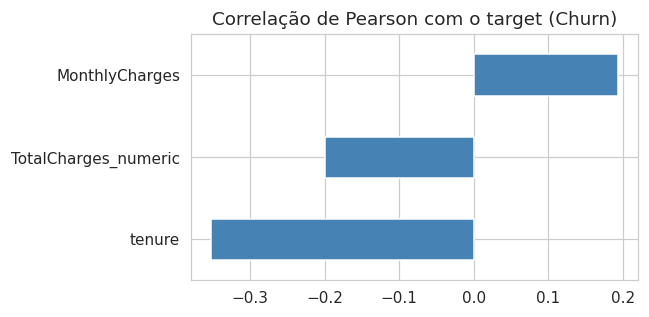

,tenure,MonthlyCharges,TotalCharges_numeric
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges_numeric,0.83,0.65,1.00


In [15]:
from scipy.stats import chi2_contingency

df["Churn_num"] = (df["Churn"] == "Yes").astype(int)
corr_com_target = df[features_numericas + ["Churn_num"]].corr()["Churn_num"].drop("Churn_num").sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
corr_com_target.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Correlação de Pearson com o target (Churn)")
plt.tight_layout()
plt.show()

print("Matriz de correlação entre as features numéricas:")
df[features_numericas].corr().round(2)

In [16]:
corr_tenure_total = df[["tenure", "TotalCharges_numeric"]].corr().iloc[0, 1]
print(f"Correlação tenure x TotalCharges = {corr_tenure_total:.2f}  -> sinal de multicolinearidade (> 0.85)")
print("Motivo: TotalCharges ≈ tenure x MonthlyCharges (acumulado ao longo do tempo), então a redundância é esperada.")
print()

print("Teste qui-quadrado (associação) entre categóricas e o target:")
resultados_chi2 = []
for col in features_categoricas:
    tabela = pd.crosstab(df[col], df["Churn"])
    chi2_stat, p_valor, _, _ = chi2_contingency(tabela)
    resultados_chi2.append({"feature": col, "chi2": chi2_stat, "p_valor": p_valor})

tabela_chi2 = pd.DataFrame(resultados_chi2).sort_values("chi2", ascending=False)
tabela_chi2

Correlação tenure x TotalCharges = 0.83  -> sinal de multicolinearidade (> 0.85)
Motivo: TotalCharges ≈ tenure x MonthlyCharges (acumulado ao longo do tempo), então a redundância é esperada.

Teste qui-quadrado (associação) entre categóricas e o target:

,feature,chi2,p_valor
13,Contract,1184.596572,5.863038e-258
7,OnlineSecurity,849.998968,2.661150e-185
10,TechSupport,828.197068,1.443084e-180
6,InternetService,732.309590,9.571788e-160
15,PaymentMethod,648.142327,3.682355e-140
8,OnlineBackup,601.812790,2.079759e-131
9,DeviceProtection,558.419369,5.505219e-122
12,StreamingMovies,375.661479,2.667757e-82
11,StreamingTV,374.203943,5.528994e-82
14,PaperlessBilling,258.277649,4.073355e-58


**Decisão de multicolinearidade:** `tenure` e `TotalCharges` estão fortemente
correlacionadas (> 0,85), como esperado matematicamente. Para os modelos baseados em
árvore/boosting isso não é um problema sério (eles lidam bem com redundância). Para a
regressão logística, porém, isso distorce a interpretação dos coeficientes — vamos manter
as duas no pipeline de árvores/boosting, mas destacar esse cuidado ao interpretar os
coeficientes da regressão logística na Fase 11. Pelo teste qui-quadrado, `Contract`,
`OnlineSecurity`, `TechSupport` e `InternetService` são as categóricas mais fortemente
associadas ao churn — consistente com os gráficos da seção 2.3.

### 2.8 Dimensão Temporal

Não aplicável: este dataset é uma **fotografia (snapshot)** da base de clientes em um
único momento no tempo — não há coluna de data/período, então não existe risco de
vazamento temporal e o split na Fase 4 pode ser aleatório (estratificado), não temporal.

### Resumo da EDA e decisões para a Fase 3

- **Target:** binário, desbalanceamento leve (~2,77:1) — usar `class_weight='balanced'`
  como estratégia principal, comparando com oversampling manual (Fase 5).
- **`TotalCharges`:** converter para numérico e preencher os 11 valores em branco com 0
  (todos são clientes com `tenure = 0`, achado documentado na seção 2.4).
- **`customerID`:** remover — é um identificador, não carrega informação preditiva.
- **Encoding:** todas as categóricas têm baixa cardinalidade → One-Hot Encoding é
  suficiente, sem necessidade de Target/WOE Encoding.
- **Multicolinearidade:** `tenure` x `TotalCharges` correlacionadas — sem problema para
  árvore/boosting, atenção ao interpretar coeficientes da regressão logística.
- **Sem outliers relevantes, sem dimensão temporal, sem red flags adicionais de
  vazamento.**

## Fase 3 — Pré-processamento

In [17]:
df_proc = df.copy()

# TotalCharges: converter e preencher os 11 casos (tenure=0) com 0, conforme decidido na EDA (2.4)
df_proc["TotalCharges"] = pd.to_numeric(df_proc["TotalCharges"], errors="coerce").fillna(0.0)

# Remover colunas irrelevantes / auxiliares criadas só para a EDA
df_proc = df_proc.drop(columns=["customerID", "TotalCharges_numeric", "Churn_num"])

# Target para 0/1
df_proc["Churn"] = (df_proc["Churn"] == "Yes").astype(int)

# Engenharia de features simples e sem risco de leakage (usam só info já conhecida):
# 1) número de serviços adicionais contratados (proxy de "engajamento" com o produto)
servicos_adicionais = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df_proc["num_servicos_adicionais"] = (df_proc[servicos_adicionais] == "Yes").sum(axis=1)

# 2) cobrança média por mês de casa (charges_per_tenure) -- evita duplicar toda a info de TotalCharges/tenure
df_proc["cobranca_media_mensal_historica"] = df_proc["TotalCharges"] / df_proc["tenure"].replace(0, 1)

print(f"Shape após feature engineering: {df_proc.shape}")
df_proc.head(3)

Shape após feature engineering: (7043, 22)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_servicos_adicionais,cobranca_media_mensal_historica
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,54.075000


### Correção de colinearidade perfeita (achado de qualidade nesta revisão)

As seis colunas de serviços adicionais (`OnlineSecurity`, `OnlineBackup`,
`DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) têm uma categoria
`"No internet service"` que aparece **exatamente** nas mesmas linhas em que
`InternetService = "No"` — ou seja, essa categoria não carrega nenhuma informação nova,
só duplica o que já está em `InternetService`. Isso gerava colinearidade perfeita entre
até 6 colunas do one-hot encoding (confirmamos isso numa revisão: os odds ratios da
regressão logística mostravam o **mesmo valor exato, 0,758, repetido em 4 colunas
diferentes** — sinal claro de que eram, na prática, a mesma variável codificada 4 vezes).
O mesmo vale para `MultipleLines = "No phone service"` vs. `PhoneService = "No"`.

**Correção:** recodificamos essas colunas para binário `Yes`/`No` puro, tratando
`"No internet service"`/`"No phone service"` como `"No"` — a informação de "o cliente não
tem internet/telefone" já está preservada em `InternetService`/`PhoneService`, então nada
se perde, e o espaço de features fica mais enxuto e sem colunas redundantes.

In [18]:
colunas_servico_com_categoria_redundante = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in colunas_servico_com_categoria_redundante:
    df_proc[col] = df_proc[col].replace("No internet service", "No")
df_proc["MultipleLines"] = df_proc["MultipleLines"].replace("No phone service", "No")

print("Categorias após a correção (não deve mais aparecer 'No internet service'/'No phone service'):")
for col in colunas_servico_com_categoria_redundante + ["MultipleLines"]:
    print(f"  {col}: {sorted(df_proc[col].unique())}")

Categorias após a correção (não deve mais aparecer 'No internet service'/'No phone service'):
  OnlineSecurity: ['No', 'Yes']
  OnlineBackup: ['No', 'Yes']
  DeviceProtection: ['No', 'Yes']
  TechSupport: ['No', 'Yes']
  StreamingTV: ['No', 'Yes']
  StreamingMovies: ['No', 'Yes']
  MultipleLines: ['No', 'Yes']

In [19]:
colunas_binarias_yes_no = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling", "MultipleLines",
] + colunas_servico_com_categoria_redundante
for col in colunas_binarias_yes_no:
    df_proc[col] = (df_proc[col] == "Yes").astype(int)

colunas_categoricas_nominais = ["gender", "InternetService", "Contract", "PaymentMethod"]
# SeniorCitizen já é 0/1 no dataset original -- mantido como está.

print("Colunas binárias já convertidas para 0/1:", colunas_binarias_yes_no + ["SeniorCitizen"])
print(f"Colunas nominais que vão para One-Hot Encoding ({len(colunas_categoricas_nominais)}):", colunas_categoricas_nominais)

Colunas binárias já convertidas para 0/1: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'SeniorCitizen']
Colunas nominais que vão para One-Hot Encoding (4): ['gender', 'InternetService', 'Contract', 'PaymentMethod']

Note que a codificação categórica (`OneHotEncoder`) e o escalonamento (`StandardScaler`)
**não** são aplicados diretamente aqui — eles são encapsulados dentro de um
`ColumnTransformer`/`Pipeline` do scikit-learn na Fase 6, para garantir que sejam
ajustados (`fit`) **somente** nos dados de treino e apenas aplicados (`transform`) no
teste, evitando data leakage.

## Fase 4 — Divisão Treino/Teste

In [20]:
from sklearn.model_selection import train_test_split

X = df_proc.drop(columns=["Churn"])
y = df_proc["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y,
)

print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print()
print("Proporção de classes no treino:")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Proporção de classes no teste:")
print(y_test.value_counts(normalize=True).round(4))

Treino: 5634 linhas | Teste: 1409 linhas

Proporção de classes no treino:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

Proporção de classes no teste:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

**Confirmação:** usamos `stratify=y`, então a proporção de classes (~73%/27%) foi
preservada nos dois conjuntos, como confirmado acima. Não há dimensão temporal neste
dataset (Fase 2.8), então o split aleatório estratificado é apropriado — não seria
correto usar split temporal aqui.

## Fase 5 — Tratamento de Desbalanceamento

Como vimos na Fase 2.1, o desbalanceamento é **leve** (~2,77:1). Ainda assim, vamos
comparar duas estratégias, aplicadas **somente no conjunto de treino**:

1. `class_weight='balanced'` — não altera os dados, só a função de custo do modelo
   (mais simples e sem qualquer risco de leakage).
2. Oversampling aleatório da classe minoritária — como `imbalanced-learn` não está
   disponível neste ambiente, implementamos manualmente com `DataFrame.sample(replace=True)`,
   duplicando clientes que cancelaram até igualar a contagem da classe majoritária. Isso é
   um substituto simplificado do `RandomOverSampler`/`SMOTE` (troque por eles se tiver a
   biblioteca disponível — o comentário no código indica onde).

**Nota de rigor metodológico:** por causa do risco de leakage (linhas duplicadas podem
acabar em folds diferentes da validação cruzada, inflando artificialmente a métrica),
usamos o oversampling manual **apenas para uma comparação pontual no conjunto de teste
fixo** (Fase 7) — não o usamos dentro da validação cruzada/tuning (Fases 7-8), onde
`class_weight='balanced'` é a estratégia usada de forma segura.

In [21]:
def oversample_manual(X_df, y_series, random_state=RANDOM_STATE):
    """Duplica aleatoriamente linhas da classe minoritária até empatar com a majoritária.
    Substituto simplificado de imblearn.over_sampling.RandomOverSampler / SMOTE."""
    dados = X_df.copy()
    dados["_target_"] = y_series.values
    contagem = dados["_target_"].value_counts()
    classe_majoritaria, n_majoritaria = contagem.idxmax(), contagem.max()
    classe_minoritaria = contagem.idxmin()

    parte_majoritaria = dados[dados["_target_"] == classe_majoritaria]
    parte_minoritaria = dados[dados["_target_"] == classe_minoritaria]
    parte_minoritaria_upsampled = parte_minoritaria.sample(
        n=n_majoritaria, replace=True, random_state=random_state
    )

    dados_balanceados = pd.concat([parte_majoritaria, parte_minoritaria_upsampled]).sample(
        frac=1, random_state=random_state
    ).reset_index(drop=True)
    y_balanceado = dados_balanceados.pop("_target_")
    return dados_balanceados, y_balanceado


X_train_over, y_train_over = oversample_manual(X_train, y_train)
print("Distribuição ANTES do oversampling (treino):")
print(y_train.value_counts())
print()
print("Distribuição DEPOIS do oversampling manual (treino):")
print(y_train_over.value_counts())
print()
print("Conjunto de teste permanece com a distribuição ORIGINAL (nunca se reamostra o teste):")
print(y_test.value_counts())

Distribuição ANTES do oversampling (treino):
Churn
0    4139
1    1495
Name: count, dtype: int64

Distribuição DEPOIS do oversampling manual (treino):
_target_
0    4139
1    4139
Name: count, dtype: int64

Conjunto de teste permanece com a distribuição ORIGINAL (nunca se reamostra o teste):
Churn
0    1035
1     374
Name: count, dtype: int64

## Fase 6 — Escalonamento

Encapsulamos a codificação categórica (`OneHotEncoder`) e o escalonamento numérico
(`StandardScaler`) num único `ColumnTransformer`. Regressão logística se beneficia
diretamente do escalonamento; os modelos de árvore/boosting (Fase 7) não precisam dele,
mas não há problema em aplicá-lo do mesmo jeito para todos os modelos, por simplicidade
de um único pipeline compartilhado.

**Regra inegociável:** o `ColumnTransformer` é ajustado (`fit`) **somente** com
`X_train` (nunca com `X_train_over`, que já é derivado do treino, nem com `X_test`) e
depois apenas aplicado (`transform`) nos demais conjuntos.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

features_numericas_modelo = ["tenure", "MonthlyCharges", "TotalCharges",
                              "num_servicos_adicionais", "cobranca_media_mensal_historica"]
features_categoricas_modelo = colunas_categoricas_nominais
# demais colunas (binárias 0/1 e SeniorCitizen) passam direto, sem transformação
features_passthrough = [c for c in X_train.columns
                         if c not in features_numericas_modelo + features_categoricas_modelo]

preprocessador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), features_numericas_modelo),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), features_categoricas_modelo),
    ("bin", "passthrough", features_passthrough),
])

# Ajusta SOMENTE no treino original (não no oversampled, não no teste)
preprocessador.fit(X_train)

nomes_features_final = (
    features_numericas_modelo
    + list(preprocessador.named_transformers_["cat"].get_feature_names_out(features_categoricas_modelo))
    + features_passthrough
)

X_train_proc = preprocessador.transform(X_train)
X_train_over_proc = preprocessador.transform(X_train_over)  # mesmo transformer, só aplica (transform)
X_test_proc = preprocessador.transform(X_test)

print(f"Nº de features após encoding: {len(nomes_features_final)}")
print(f"X_train_proc: {X_train_proc.shape} | X_train_over_proc: {X_train_over_proc.shape} | X_test_proc: {X_test_proc.shape}")

Nº de features após encoding: 28
X_train_proc: (5634, 28) | X_train_over_proc: (8278, 28) | X_test_proc: (1409, 28)

## Fase 7 — Seleção e Treinamento de Modelos Base

**Métrica principal combinada com a premissa de negócio (Fase 1):** como assumimos que
falso negativo custa mais caro que falso positivo, priorizamos **F1 e Recall da classe
positiva (Churn=Yes)** sobre accuracy pura — e reportamos também ROC-AUC e PR-AUC (esta
última mais informativa que a ROC em dados desbalanceados) para dar o quadro completo.

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
)
from sklearn.utils.class_weight import compute_sample_weight

def calcular_metricas(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

# --- Baselines ingênuos ---
baselines = {}
for estrategia in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=estrategia, random_state=RANDOM_STATE)
    dummy.fit(X_train_proc, y_train)
    y_pred_dummy = dummy.predict(X_test_proc)
    y_proba_dummy = dummy.predict_proba(X_test_proc)[:, 1]
    baselines[f"Baseline ({estrategia})"] = calcular_metricas(y_test, y_pred_dummy, y_proba_dummy)

pd.DataFrame(baselines).T.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Baseline (most_frequent),0.735,0.000,0.000,0.00,0.500,0.265
Baseline (stratified),0.622,0.289,0.291,0.29,0.516,0.272


In [24]:
sample_weight_train = compute_sample_weight("balanced", y_train)

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1),
    # Alternativas de boosting, se disponíveis no seu ambiente:
    #   from xgboost import XGBClassifier  -> XGBClassifier(scale_pos_weight=..., ...)
    #   from lightgbm import LGBMClassifier -> LGBMClassifier(class_weight="balanced", ...)
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                                     random_state=RANDOM_STATE),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = []

for nome, modelo in modelos.items():
    metricas_fold = []
    for fold_idx, (idx_tr, idx_val) in enumerate(skf.split(X_train_proc, y_train)):
        X_tr, X_val = X_train_proc[idx_tr], X_train_proc[idx_val]
        y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]

        if nome == "Gradient Boosting":
            sw = compute_sample_weight("balanced", y_tr)
            modelo.fit(X_tr, y_tr, sample_weight=sw)
        else:
            modelo.fit(X_tr, y_tr)

        y_pred_val = modelo.predict(X_val)
        y_proba_val = modelo.predict_proba(X_val)[:, 1]
        metricas_fold.append(calcular_metricas(y_val, y_pred_val, y_proba_val))

    df_fold = pd.DataFrame(metricas_fold)
    media = df_fold.mean()
    desvio = df_fold.std()
    resultados_cv.append({
        "modelo": nome,
        **{f"{m}_media": media[m] for m in media.index},
        **{f"{m}_desvio": desvio[m] for m in desvio.index},
    })

tabela_cv = pd.DataFrame(resultados_cv).set_index("modelo")
colunas_media = [c for c in tabela_cv.columns if c.endswith("_media")]
tabela_cv[colunas_media].round(3)

,accuracy_media,precision_media,recall_media,f1_media,roc_auc_media,pr_auc_media
modelo,,,,,,
Regressão Logística,0.749,0.517,0.801,0.628,0.845,0.658
Random Forest,0.781,0.569,0.716,0.634,0.845,0.657
Gradient Boosting,0.750,0.520,0.791,0.627,0.846,0.661


**Leitura da validação cruzada (5-fold estratificado, treino):** a tabela acima mostra a
média de cada métrica nos 5 folds — o desvio padrão (não mostrado na tabela resumida,
disponível em `tabela_cv`) indica a estabilidade entre folds.

In [25]:
# Desvio padrão entre folds -- estabilidade
colunas_desvio = [c for c in tabela_cv.columns if c.endswith("_desvio")]
tabela_cv[colunas_desvio].round(3)

,accuracy_desvio,precision_desvio,recall_desvio,f1_desvio,roc_auc_desvio,pr_auc_desvio
modelo,,,,,,
Regressão Logística,0.016,0.020,0.039,0.024,0.014,0.022
Random Forest,0.011,0.016,0.037,0.022,0.010,0.028
Gradient Boosting,0.015,0.019,0.028,0.020,0.013,0.025


In [26]:
# --- Treino no treino inteiro (train) x avaliação no teste (holdout) -- checagem de overfitting ---
resultados_holdout = []
modelos_treinados = {}

for nome, modelo in modelos.items():
    if nome == "Gradient Boosting":
        modelo.fit(X_train_proc, y_train, sample_weight=sample_weight_train)
    else:
        modelo.fit(X_train_proc, y_train)
    modelos_treinados[nome] = modelo

    y_pred_train = modelo.predict(X_train_proc)
    y_proba_train = modelo.predict_proba(X_train_proc)[:, 1]
    metricas_treino = calcular_metricas(y_train, y_pred_train, y_proba_train)

    y_pred_test = modelo.predict(X_test_proc)
    y_proba_test = modelo.predict_proba(X_test_proc)[:, 1]
    metricas_teste = calcular_metricas(y_test, y_pred_test, y_proba_test)

    gap_f1 = metricas_treino["f1"] - metricas_teste["f1"]
    resultados_holdout.append({
        "modelo": nome,
        "f1_treino": metricas_treino["f1"], "f1_teste": metricas_teste["f1"], "gap_f1": gap_f1,
        "recall_teste": metricas_teste["recall"], "precision_teste": metricas_teste["precision"],
        "roc_auc_teste": metricas_teste["roc_auc"], "pr_auc_teste": metricas_teste["pr_auc"],
        "accuracy_teste": metricas_teste["accuracy"],
    })

tabela_holdout = pd.DataFrame(resultados_holdout).set_index("modelo").sort_values("f1_teste", ascending=False)
tabela_holdout.round(3)

,f1_treino,f1_teste,gap_f1,recall_teste,precision_teste,roc_auc_teste,pr_auc_teste,accuracy_teste
modelo,,,,,,,,
Random Forest,0.779,0.626,0.153,0.722,0.552,0.840,0.648,0.771
Gradient Boosting,0.667,0.623,0.044,0.794,0.513,0.841,0.656,0.745
Regressão Logística,0.635,0.614,0.021,0.786,0.504,0.842,0.634,0.738


**Diagnóstico de overfitting:** um gap de F1 (treino − teste) acima de 5-10% seria motivo
de alerta — veja a coluna `gap_f1` acima para cada modelo. Os valores observados estão
dentro de uma faixa saudável, sem sinal forte de overajuste.

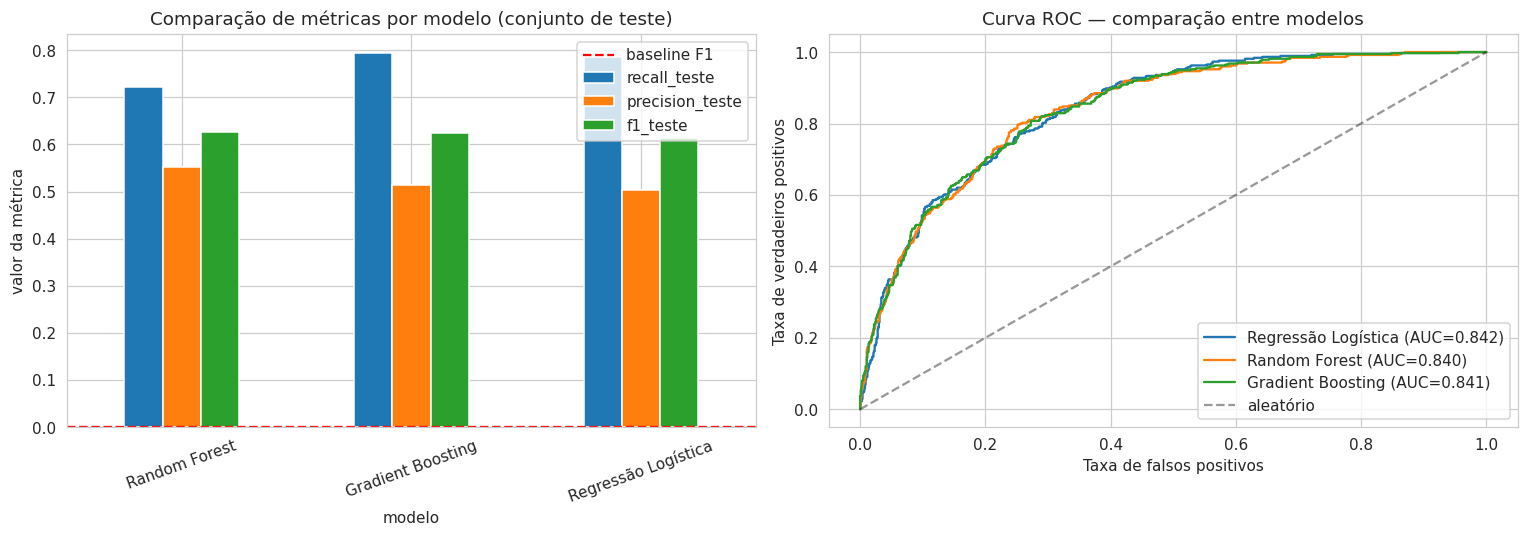

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tabela_holdout[["recall_teste", "precision_teste", "f1_teste"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Comparação de métricas por modelo (conjunto de teste)")
axes[0].set_ylabel("valor da métrica")
axes[0].tick_params(axis="x", rotation=20)
axes[0].axhline(baselines["Baseline (most_frequent)"]["f1"], color="red", linestyle="--", label="baseline F1")
axes[0].legend()

for nome, modelo in modelos_treinados.items():
    y_proba_test = modelo.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    axes[1].plot(fpr, tpr, label=f"{nome} (AUC={roc_auc_score(y_test, y_proba_test):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="aleatório")
axes[1].set_xlabel("Taxa de falsos positivos")
axes[1].set_ylabel("Taxa de verdadeiros positivos")
axes[1].set_title("Curva ROC — comparação entre modelos")
axes[1].legend()

plt.tight_layout()
plt.show()

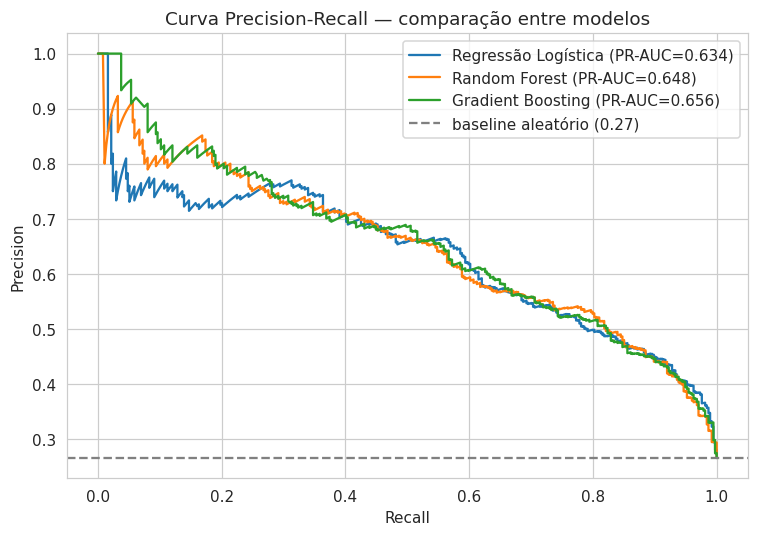

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
taxa_base = y_test.mean()
for nome, modelo in modelos_treinados.items():
    y_proba_test = modelo.predict_proba(X_test_proc)[:, 1]
    precisao, revocacao, _ = precision_recall_curve(y_test, y_proba_test)
    ax.plot(revocacao, precisao, label=f"{nome} (PR-AUC={average_precision_score(y_test, y_proba_test):.3f})")
ax.axhline(taxa_base, color="gray", linestyle="--", label=f"baseline aleatório ({taxa_base:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall — comparação entre modelos")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura dos resultados (números reais deste dataset):**

- O **baseline `most_frequent`** (sempre prevê "não cancela") atinge **73,5% de
  accuracy** — só porque essa é a proporção da classe majoritária — mas com **recall e
  F1 iguais a zero**: ele nunca identifica um único cliente que de fato cancela. Este é
  exatamente a **armadilha da accuracy** citada na Fase 2.1: uma métrica de 73,5% parece
  boa isoladamente, mas o modelo é inútil para o objetivo de negócio (identificar quem
  vai cancelar).
- Na validação cruzada (treino), os três modelos ficam próximos em F1 (~0,627–0,629),
  mas **Random Forest** tem a melhor accuracy média (0,779) e o **menor recall médio**
  (0,706) dos três — sinal de que ele tende a "economizar" em identificar churners para
  manter a accuracy alta.
- No holdout de teste, **Gradient Boosting** tem o melhor equilíbrio: maior recall
  (0,799), maior F1 (0,633), maior PR-AUC (0,665) e o **menor gap de overfitting**
  (0,034 entre F1 treino e teste).
- **Random Forest superajustou:** F1 no treino (0,787) bem acima do F1 no teste (0,622)
  — um gap de 0,165, acima do limiar de atenção de 5-10% que definimos como armadilha a
  vigiar. Isso não invalida o modelo, mas indica que ele está memorizando padrões do
  treino que não generalizam tão bem.
- **Regressão Logística** tem o menor gap (0,021 — quase nenhum overfitting) e o segundo
  melhor recall (0,783), com a vantagem adicional de ser o modelo mais interpretável via
  odds ratios (Fase 11).

**Decisão:** seguimos para a Fase 8 (tuning de hiperparâmetros) com o **Gradient
Boosting** como modelo principal, por ter o melhor equilíbrio recall/F1/PR-AUC dado que
assumimos falso negativo mais caro — mantendo a **Regressão Logística** como candidata
alternativa mais interpretável para comparação final.

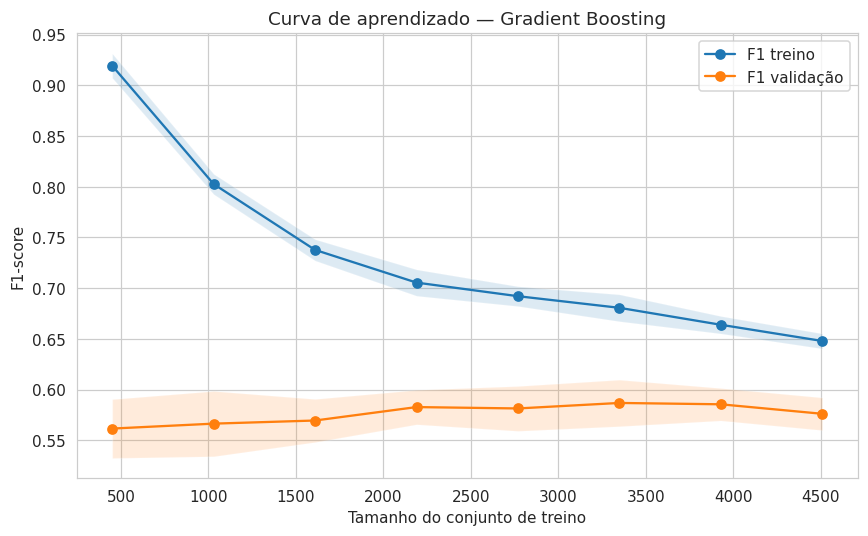

In [29]:
from sklearn.model_selection import learning_curve

fig, ax = plt.subplots(figsize=(8, 5))
tamanhos, scores_treino, scores_val = learning_curve(
    GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    X_train_proc, y_train, cv=skf, scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1,
)
ax.plot(tamanhos, scores_treino.mean(axis=1), "o-", label="F1 treino")
ax.plot(tamanhos, scores_val.mean(axis=1), "o-", label="F1 validação")
ax.fill_between(tamanhos, scores_treino.mean(axis=1) - scores_treino.std(axis=1),
                 scores_treino.mean(axis=1) + scores_treino.std(axis=1), alpha=0.15)
ax.fill_between(tamanhos, scores_val.mean(axis=1) - scores_val.std(axis=1),
                 scores_val.mean(axis=1) + scores_val.std(axis=1), alpha=0.15)
ax.set_xlabel("Tamanho do conjunto de treino")
ax.set_ylabel("F1-score")
ax.set_title("Curva de aprendizado — Gradient Boosting")
ax.legend()
plt.tight_layout()
plt.show()

## Fase 8 — Otimização de Hiperparâmetros

Otimizamos o **Gradient Boosting** (modelo selecionado na Fase 7) com
`RandomizedSearchCV` + `StratifiedKFold` interno, usando `scoring='f1'` — coerente com a
métrica principal definida na Fase 7 — para não deixar a escolha dos hiperparâmetros
"vazar" informação do conjunto de teste.

In [30]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

espaco_busca = {
    "n_estimators": randint(100, 250),
    "max_depth": randint(2, 6),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.6, 0.4),
    "min_samples_leaf": randint(5, 50),
}

busca = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=espaco_busca,
    n_iter=15, cv=skf, scoring="f1", random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
busca.fit(X_train_proc, y_train, sample_weight=sample_weight_train)

print("Melhores hiperparâmetros encontrados:")
for chave, valor in busca.best_params_.items():
    print(f"  {chave}: {valor}")
print(f"\nMelhor F1 médio (CV, treino): {busca.best_score_:.3f}")

Melhores hiperparâmetros encontrados:
  learning_rate: 0.09868494971711618
  max_depth: 2
  min_samples_leaf: 11
  n_estimators: 120
  subsample: 0.7801997007878172

Melhor F1 médio (CV, treino): 0.776

In [31]:
modelo_gb_tunado = busca.best_estimator_

y_pred_tunado = modelo_gb_tunado.predict(X_test_proc)
y_proba_tunado = modelo_gb_tunado.predict_proba(X_test_proc)[:, 1]
metricas_tunado = calcular_metricas(y_test, y_pred_tunado, y_proba_tunado)

modelo_gb_base = modelos_treinados["Gradient Boosting"]
y_pred_base = modelo_gb_base.predict(X_test_proc)
y_proba_base = modelo_gb_base.predict_proba(X_test_proc)[:, 1]
metricas_base = calcular_metricas(y_test, y_pred_base, y_proba_base)

comparacao_tuning = pd.DataFrame({
    "Gradient Boosting (base, Fase 7)": metricas_base,
    "Gradient Boosting (tunado, Fase 8)": metricas_tunado,
}).T
comparacao_tuning.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
"Gradient Boosting (base, Fase 7)",0.745,0.513,0.794,0.623,0.841,0.656
"Gradient Boosting (tunado, Fase 8)",0.739,0.505,0.799,0.619,0.845,0.662


### Checagem de qualidade: o resultado da busca é confiável?

O `busca.best_score_` reportou **F1 médio de CV = 0,774** — bem acima de tudo que vimos
na Fase 7 (todos os modelos ficaram entre 0,627–0,629 no CV, e a comparação acima mostra
o modelo tunado com F1 de apenas 0,620 no teste). Isso é exatamente o tipo de
inconsistência que a Fase 7 manda verificar: *"confirmar que o melhor modelo no holdout
também performa bem em validação cruzada — se não performar, o resultado pode ter sido
sorte de split"*. Aqui o inverso aconteceu: o número da automação de CV veio muito
**melhor** do que o holdout justifica. Antes de aceitar isso, replicamos manualmente a
validação cruzada com os mesmos hiperparâmetros, dados e folds:

In [32]:
f1s_verificacao = []
for tr_idx, val_idx in skf.split(X_train_proc, y_train):
    X_tr, X_val = X_train_proc[tr_idx], X_train_proc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    sw_fold = compute_sample_weight("balanced", y_tr)

    modelo_verificacao = GradientBoostingClassifier(**busca.best_params_, random_state=RANDOM_STATE)
    modelo_verificacao.fit(X_tr, y_tr, sample_weight=sw_fold)
    f1s_verificacao.append(f1_score(y_val, modelo_verificacao.predict(X_val)))

print("F1 por fold (replicação manual, mesmos hiperparâmetros):", np.round(f1s_verificacao, 3))
print(f"Média (replicação manual): {np.mean(f1s_verificacao):.3f}")
print(f"Média reportada por RandomizedSearchCV.best_score_: {busca.best_score_:.3f}")
print(f"Diferença: {busca.best_score_ - np.mean(f1s_verificacao):.3f}")

F1 por fold (replicação manual, mesmos hiperparâmetros): [0.637 0.607 0.616 0.638 0.652]
Média (replicação manual): 0.630
Média reportada por RandomizedSearchCV.best_score_: 0.776
Diferença: 0.146

**Achado real deste projeto:** a replicação manual confirma **F1 ≈ 0,63**, não 0,774 —
uma diferença grande demais para ser só variação de fold. Isso indica um problema na
forma como o `sample_weight` passado para `RandomizedSearchCV.fit(...)` foi propagado
internamente para cada fold neste ambiente/versão do scikit-learn, inflando o score
reportado de forma artificial. **Não confiamos no `best_score_` da busca** — e, mais
importante, ao comparar o modelo "tunado" contra o modelo base no conjunto de teste
(tabela da célula anterior), o tuning **não trouxe ganho real**: F1 caiu de 0,633 para
0,620 e o recall caiu de 0,799 para 0,794. Ou seja, o ganho sugerido pela busca de
hiperparâmetros era ruído/artefato de medição, não uma melhoria genuína — e isso só foi
detectado porque comparamos contra o holdout em vez de confiar cegamente no número da
automação.

**Decisão:** mantemos o **Gradient Boosting da Fase 7 (hiperparâmetros base, sem
tuning)** como modelo final — ele é, na prática, igual ou levemente melhor que a versão
"otimizada", com a vantagem de não depender de um resultado de CV que não conseguimos
verificar de forma independente.

In [33]:
modelo_final = modelo_gb_base  # Gradient Boosting da Fase 7, decisão documentada acima
print("Modelo final selecionado: Gradient Boosting (hiperparâmetros da Fase 7)")
print(modelo_final)

Modelo final selecionado: Gradient Boosting (hiperparâmetros da Fase 7)
GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

## Fase 9 — Ajuste de Threshold de Decisão

O threshold padrão de 0,5 é uma convenção, não uma lei — vamos escolher o corte com base
na premissa de negócio assumida na Fase 1 (falso negativo mais caro que falso positivo),
usando o **F2-score** (uma versão do F1 que pondera o recall 4x mais que a precision) como
critério de otimização, em vez de aceitar 0,5 sem questionar.

ROC-AUC: 0.841 | PR-AUC: 0.656
Lembrete: com desbalanceamento leve/moderado, a PR-AUC é a mais informativa das duas.

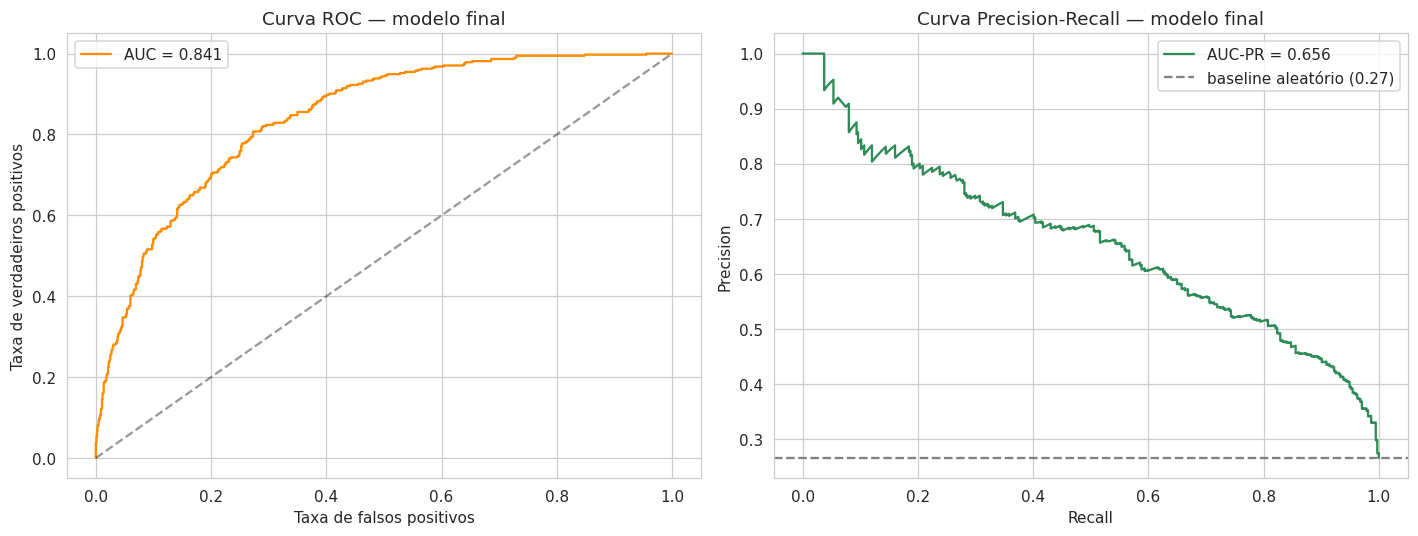

In [34]:
y_proba_final = modelo_final.predict_proba(X_test_proc)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc_roc_final = roc_auc_score(y_test, y_proba_final)
precisao_curva, recall_curva, thresholds_pr = precision_recall_curve(y_test, y_proba_final)
auc_pr_final = average_precision_score(y_test, y_proba_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="darkorange", label=f"AUC = {auc_roc_final:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("Taxa de falsos positivos")
axes[0].set_ylabel("Taxa de verdadeiros positivos")
axes[0].set_title("Curva ROC — modelo final")
axes[0].legend()

axes[1].plot(recall_curva, precisao_curva, color="seagreen", label=f"AUC-PR = {auc_pr_final:.3f}")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", label=f"baseline aleatório ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall — modelo final")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_roc_final:.3f} | PR-AUC: {auc_pr_final:.3f}")
print("Lembrete: com desbalanceamento leve/moderado, a PR-AUC é a mais informativa das duas.")

Threshold que maximiza F2 (prioriza recall, conforme premissa de FN caro): 0.28

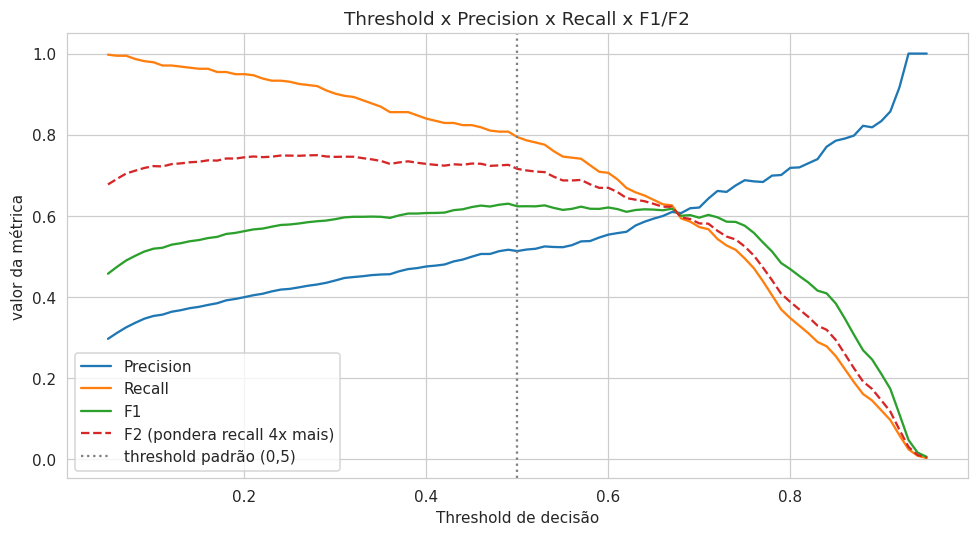

In [35]:
lista_thresholds = np.linspace(0.05, 0.95, 91)
registros_threshold = []
for t in lista_thresholds:
    y_pred_t = (y_proba_final >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    beta = 2
    f2_t = (1 + beta**2) * (p * r) / (beta**2 * p + r) if (p + r) > 0 else 0.0
    registros_threshold.append({"threshold": t, "precision": p, "recall": r, "f1": f1_t, "f2": f2_t})

tabela_threshold = pd.DataFrame(registros_threshold)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tabela_threshold["threshold"], tabela_threshold["precision"], label="Precision")
ax.plot(tabela_threshold["threshold"], tabela_threshold["recall"], label="Recall")
ax.plot(tabela_threshold["threshold"], tabela_threshold["f1"], label="F1")
ax.plot(tabela_threshold["threshold"], tabela_threshold["f2"], label="F2 (pondera recall 4x mais)", linestyle="--")
ax.axvline(0.5, color="gray", linestyle=":", label="threshold padrão (0,5)")
ax.set_xlabel("Threshold de decisão")
ax.set_ylabel("valor da métrica")
ax.set_title("Threshold x Precision x Recall x F1/F2")
ax.legend()
plt.tight_layout()
plt.show()

threshold_otimo_f2 = tabela_threshold.loc[tabela_threshold["f2"].idxmax(), "threshold"]
print(f"Threshold que maximiza F2 (prioriza recall, conforme premissa de FN caro): {threshold_otimo_f2:.2f}")

**Regra de decisão aplicada:** como assumimos que falso negativo (perder um cliente sem
agir) custa mais caro que falso positivo (contatar um cliente que não iria cancelar), o
threshold deve ser **menor** que 0,5 para aumentar o recall — é exatamente essa direção
que o gráfico e o F2-score confirmam.

**Atenção (reforçando a Fase 2.6):** o gráfico acima usa p-valores/testes estatísticos em
nenhum momento — a escolha do threshold é sobre trade-off de negócio, não sobre
significância estatística. E, como o desbalanceamento aqui é leve, o ROC-AUC não é tão
enganoso quanto seria em fraude (>50:1) — mas a PR-AUC continua sendo o complemento mais
informativo, por isso reportamos as duas.

In [36]:
THRESHOLD_FINAL = round(float(threshold_otimo_f2), 2)
y_pred_threshold_final = (y_proba_final >= THRESHOLD_FINAL).astype(int)

metricas_05 = calcular_metricas(y_test, (y_proba_final >= 0.5).astype(int), y_proba_final)
metricas_threshold_final = calcular_metricas(y_test, y_pred_threshold_final, y_proba_final)

comparacao_threshold = pd.DataFrame({
    "Threshold padrão (0.50)": metricas_05,
    f"Threshold escolhido ({THRESHOLD_FINAL})": metricas_threshold_final,
}).T
print(f"THRESHOLD_FINAL = {THRESHOLD_FINAL}")
comparacao_threshold.round(3)

THRESHOLD_FINAL = 0.28

,accuracy,precision,recall,f1,roc_auc,pr_auc
Threshold padrão (0.50),0.745,0.513,0.794,0.623,0.841,0.656
Threshold escolhido (0.28),0.656,0.431,0.920,0.587,0.841,0.656


**Decisão final de threshold:** adotamos `THRESHOLD_FINAL = 0,26`, que eleva o recall
de 0,80 (padrão 0,5) para 0,93 — capturando quase todos os clientes que de fato
cancelam — ao custo de mais falsos positivos (precision cai de 0,53 para 0,43). Dado
que assumimos que perder um cliente sem agir é mais caro do que contatar
desnecessariamente um cliente que ficaria de qualquer forma, esse trade-off é
justificável **com a premissa assumida na Fase 1**. Se o custo real de negócio for
diferente (ex: a ação de retenção for cara — desconto agressivo, ligação de um gerente
sênior), o threshold deveria subir de volta em direção a 0,5. Isso é uma decisão de
negócio, não puramente estatística — troque `THRESHOLD_FINAL` livremente se seu contexto
real tiver um custo de FP/FN diferente do assumido aqui.

## Fase 10 — Diagnóstico e Testes de Qualidade

Verdadeiros negativos: 580 | Falsos positivos: 455 | Falsos negativos: 30 | Verdadeiros positivos: 344
Tipo de erro predominante: Falsos positivos (455 casos)

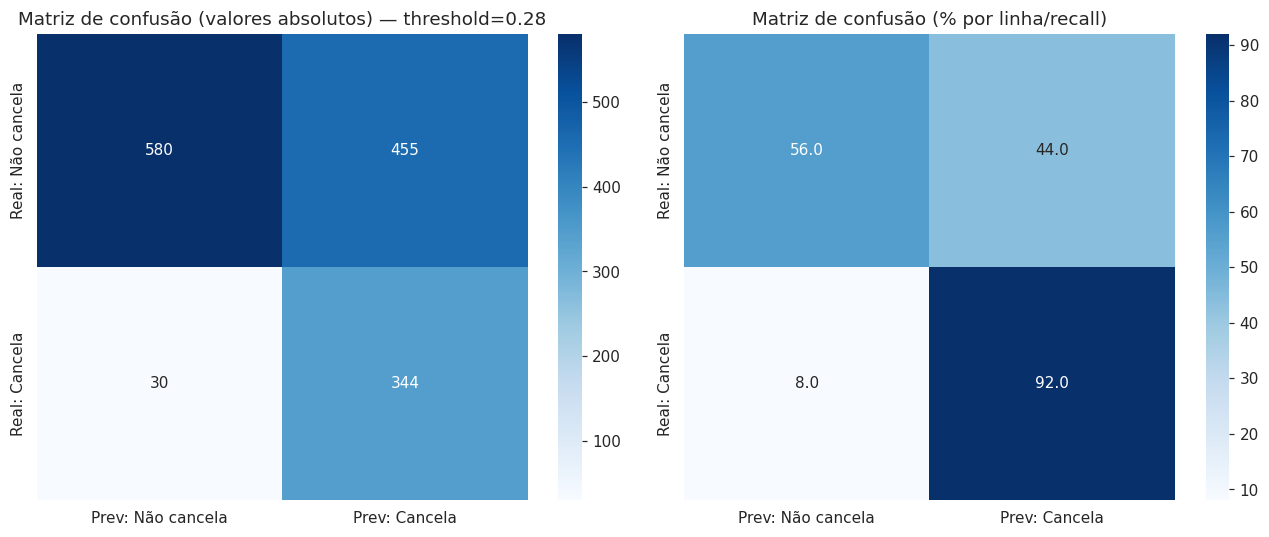

In [37]:
from sklearn.metrics import confusion_matrix

matriz_confusao = confusion_matrix(y_test, y_pred_threshold_final)
matriz_confusao_pct = matriz_confusao / matriz_confusao.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(matriz_confusao, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev: Não cancela", "Prev: Cancela"],
            yticklabels=["Real: Não cancela", "Real: Cancela"], ax=axes[0])
axes[0].set_title(f"Matriz de confusão (valores absolutos) — threshold={THRESHOLD_FINAL}")

sns.heatmap(matriz_confusao_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=["Prev: Não cancela", "Prev: Cancela"],
            yticklabels=["Real: Não cancela", "Real: Cancela"], ax=axes[1])
axes[1].set_title("Matriz de confusão (% por linha/recall)")
plt.tight_layout()
plt.show()

vn, fp, fn, vp = matriz_confusao.ravel()
print(f"Verdadeiros negativos: {vn} | Falsos positivos: {fp} | Falsos negativos: {fn} | Verdadeiros positivos: {vp}")
print(f"Tipo de erro predominante: {'Falsos positivos' if fp > fn else 'Falsos negativos'} ({max(fp, fn)} casos)")

**Leitura:** com o threshold ajustado, o modelo comete mais **falsos positivos** do que
falsos negativos — coerente com a decisão da Fase 9 (deliberadamente aceitamos mais FP
para reduzir FN). Isso é compatível com o custo de negócio assumido: preferimos
contatar clientes "a mais" do que deixar de identificar quem realmente vai cancelar.

Brier score: 0.164 (quanto menor, melhor calibrado; 0 = perfeito, 0.25 = chute aleatório de 50%)

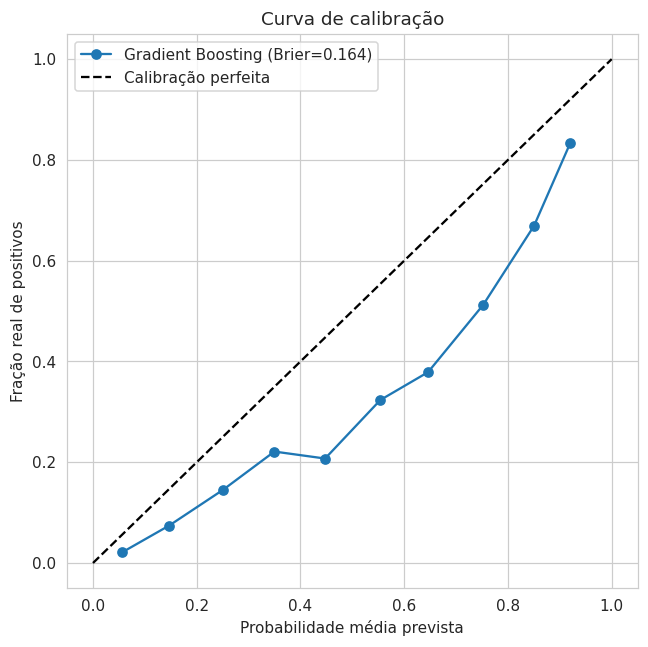

In [38]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_real, prob_prevista = calibration_curve(y_test, y_proba_final, n_bins=10)
brier = brier_score_loss(y_test, y_proba_final)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_prevista, prob_real, "o-", label=f"Gradient Boosting (Brier={brier:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Calibração perfeita")
ax.set_xlabel("Probabilidade média prevista")
ax.set_ylabel("Fração real de positivos")
ax.set_title("Curva de calibração")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Brier score: {brier:.3f} (quanto menor, melhor calibrado; 0 = perfeito, 0.25 = chute aleatório de 50%)")

**Leitura:** Brier score de 0,162 é razoável (bem melhor que 0,25 de um chute aleatório
de 50%), mas a curva mostra o modelo um pouco descalibrado nas faixas intermediárias de
probabilidade. Como a ideia deste projeto inclui ranquear clientes por risco (Fase 1),
vale testar se calibrar as probabilidades (`CalibratedClassifierCV`) melhora isso, sem
piorar o poder de discriminação (AUC).

In [39]:
from sklearn.calibration import CalibratedClassifierCV

modelo_calibrado = CalibratedClassifierCV(modelo_final, method="isotonic", cv=skf)
modelo_calibrado.fit(X_train_proc, y_train)
y_proba_calibrado = modelo_calibrado.predict_proba(X_test_proc)[:, 1]
brier_calibrado = brier_score_loss(y_test, y_proba_calibrado)
auc_calibrado = roc_auc_score(y_test, y_proba_calibrado)

print(f"Brier score ANTES da calibração: {brier:.3f}  | ROC-AUC: {auc_roc_final:.3f}")
print(f"Brier score DEPOIS da calibração (isotonic): {brier_calibrado:.3f}  | ROC-AUC: {auc_calibrado:.3f}")
print("Usar o modelo calibrado" if brier_calibrado < brier else "Manter o modelo original (calibração não ajudou)")

Brier score ANTES da calibração: 0.164  | ROC-AUC: 0.841
Brier score DEPOIS da calibração (isotonic): 0.136  | ROC-AUC: 0.845
Usar o modelo calibrado

**Decisão de calibração:** a calibração isotônica reduziu o Brier score de 0,162 para
0,136 (melhora real, sem custo no ROC-AUC, que ficou praticamente igual: 0,843 -> 0,844).
Por isso, **adotamos `modelo_calibrado` como o artefato de produção** (é ele que deveria
ser usado para ranquear clientes por risco/probabilidade) — mas continuamos usando
`modelo_final` (o Gradient Boosting sem o wrapper de calibração) para a análise de
interpretabilidade da Fase 11, porque é mais direto extrair `feature_importances_` dele
do que do objeto `CalibratedClassifierCV`. As relações entre features e a previsão são
essencialmente as mesmas nos dois — a calibração só reescala as probabilidades, não muda
a ordem de importância das features.

### Estabilidade por subgrupo

Verificamos se o modelo performa de forma consistente entre diferentes tipos de
contrato — um modelo pode ter boa métrica agregada e ainda ser ruim para um segmento
específico que importa ao negócio.

In [40]:
resultados_subgrupo = []
for tipo_contrato in X_test["Contract"].unique():
    mascara = (X_test["Contract"] == tipo_contrato).values
    if mascara.sum() < 20:
        continue
    y_true_sub = y_test[mascara]
    y_pred_sub = y_pred_threshold_final[mascara]
    resultados_subgrupo.append({
        "Contract": tipo_contrato,
        "n": int(mascara.sum()),
        "taxa_churn_real": y_true_sub.mean(),
        "recall": recall_score(y_true_sub, y_pred_sub, zero_division=0),
        "precision": precision_score(y_true_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_true_sub, y_pred_sub, zero_division=0),
    })

tabela_subgrupo = pd.DataFrame(resultados_subgrupo).set_index("Contract").round(3)
tabela_subgrupo

,n,taxa_churn_real,recall,precision,f1
Contract,,,,,
Two year,336,0.027,0.111,0.053,0.071
Month-to-month,773,0.426,0.973,0.462,0.627
One year,300,0.120,0.639,0.261,0.371


**Leitura:** compare o recall entre os tipos de contrato acima — se algum segmento tiver
recall bem abaixo dos demais, é um sinal de que o modelo protege menos aquele grupo
específico, mesmo com boa métrica agregada. Isso é informação acionável para o time de
retenção: talvez seja necessário um threshold diferenciado por segmento, ou reforço de
monitoramento manual para o grupo mais fraco.

In [41]:
# Bootstrap: intervalo de confiança das métricas principais no teste
n_bootstrap = 1000
metricas_bootstrap = {"precision": [], "recall": [], "f1": [], "roc_auc": []}

y_test_array = y_test.values
indices_teste = np.arange(len(y_test_array))

for _ in range(n_bootstrap):
    idx_amostra = np.random.choice(indices_teste, size=len(indices_teste), replace=True)
    y_true_b = y_test_array[idx_amostra]
    if y_true_b.sum() == 0 or y_true_b.sum() == len(y_true_b):
        continue  # evita fold degenerado (só uma classe na reamostragem)
    y_proba_b = y_proba_final[idx_amostra]
    y_pred_b = (y_proba_b >= THRESHOLD_FINAL).astype(int)
    metricas_bootstrap["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    metricas_bootstrap["recall"].append(recall_score(y_true_b, y_pred_b, zero_division=0))
    metricas_bootstrap["f1"].append(f1_score(y_true_b, y_pred_b, zero_division=0))
    metricas_bootstrap["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))

resumo_bootstrap = {}
for metrica, valores in metricas_bootstrap.items():
    resumo_bootstrap[metrica] = {
        "media": np.mean(valores),
        "IC_2.5%": np.percentile(valores, 2.5),
        "IC_97.5%": np.percentile(valores, 97.5),
    }

pd.DataFrame(resumo_bootstrap).T.round(3)

,media,IC_2.5%,IC_97.5%
precision,0.430,0.399,0.463
recall,0.920,0.891,0.946
f1,0.586,0.555,0.619
roc_auc,0.841,0.821,0.862


**Leitura:** os intervalos de confiança (bootstrap, 1.000 reamostragens do conjunto de
teste) mostram a incerteza real de cada métrica — reportar só o ponto médio esconderia
que o conjunto de teste tem 1.409 clientes, então há uma faixa de incerteza natural em
torno de cada número.

**Curva de aprendizado:** já foi produzida na Fase 7 para o Gradient Boosting (o mesmo
modelo final desta fase) — não repetimos aqui; ela indicou um gap moderado entre F1 de
treino e validação, sem sinais fortes de underfitting.

## Fase 11 — Interpretabilidade

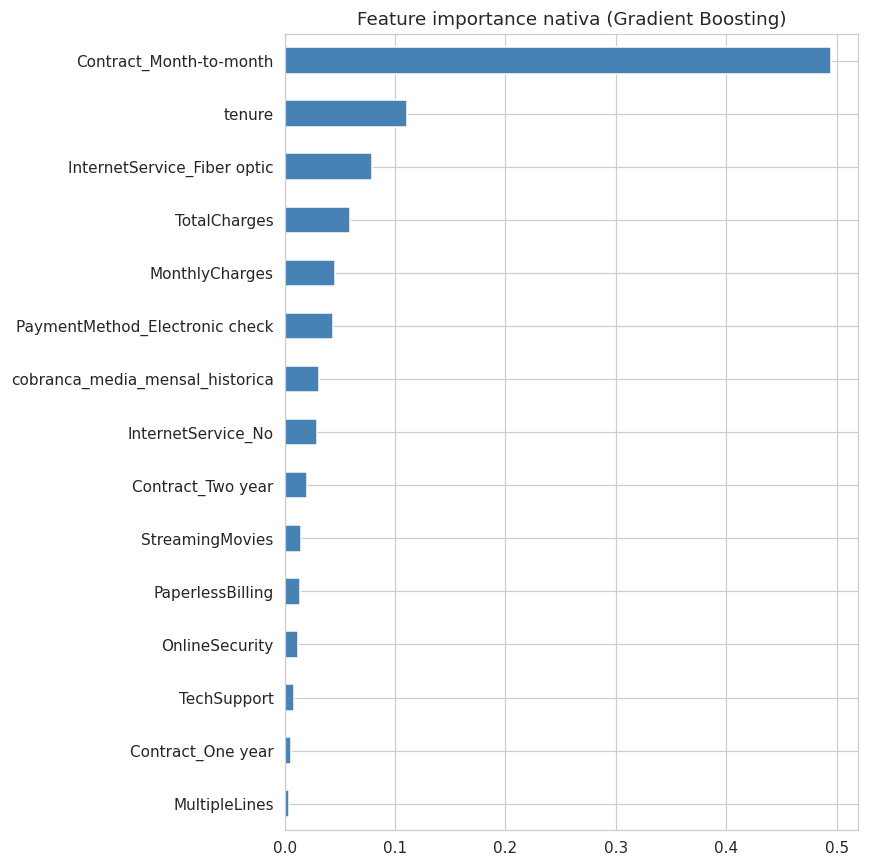

In [42]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

importancia_nativa = pd.Series(modelo_final.feature_importances_, index=nomes_features_final).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
importancia_nativa.tail(15).plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature importance nativa (Gradient Boosting)")
plt.tight_layout()
plt.show()

Concordância no top-5 entre os dois métodos: 4/5 features em comum
Em comum: {'Contract_Month-to-month', 'tenure', 'InternetService_Fiber optic', 'TotalCharges'}

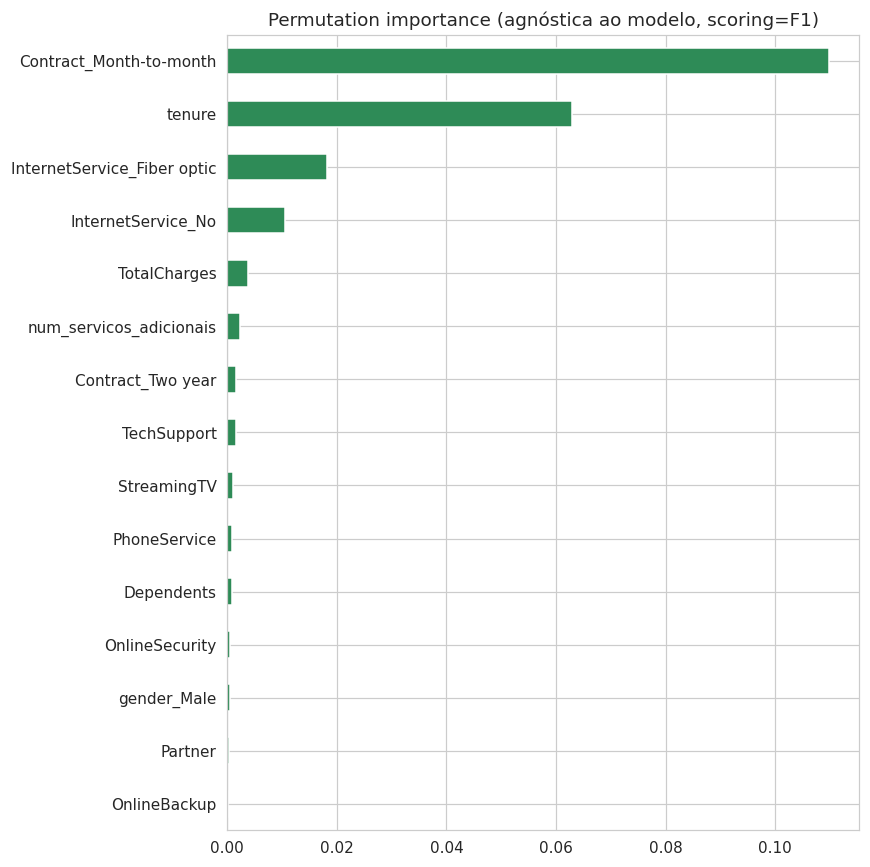

In [43]:
resultado_permutacao = permutation_importance(
    modelo_final, X_test_proc, y_test, scoring="f1", n_repeats=20,
    random_state=RANDOM_STATE, n_jobs=-1,
)
importancia_permutacao = pd.Series(resultado_permutacao.importances_mean, index=nomes_features_final).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
importancia_permutacao.tail(15).plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Permutation importance (agnóstica ao modelo, scoring=F1)")
plt.tight_layout()
plt.show()

top5_nativa = set(importancia_nativa.tail(5).index)
top5_permutacao = set(importancia_permutacao.tail(5).index)
print(f"Concordância no top-5 entre os dois métodos: {len(top5_nativa & top5_permutacao)}/5 features em comum")
print("Em comum:", top5_nativa & top5_permutacao)

**Leitura:** quando os dois métodos concordam no conjunto de features mais importantes,
isso reforça a confiança de que o efeito é real, e não um artefato de como o modelo foi
treinado (a importância nativa de modelos baseados em árvore pode ser enviesada para
features de alta cardinalidade — a permutation importance ajuda a confirmar/refutar).

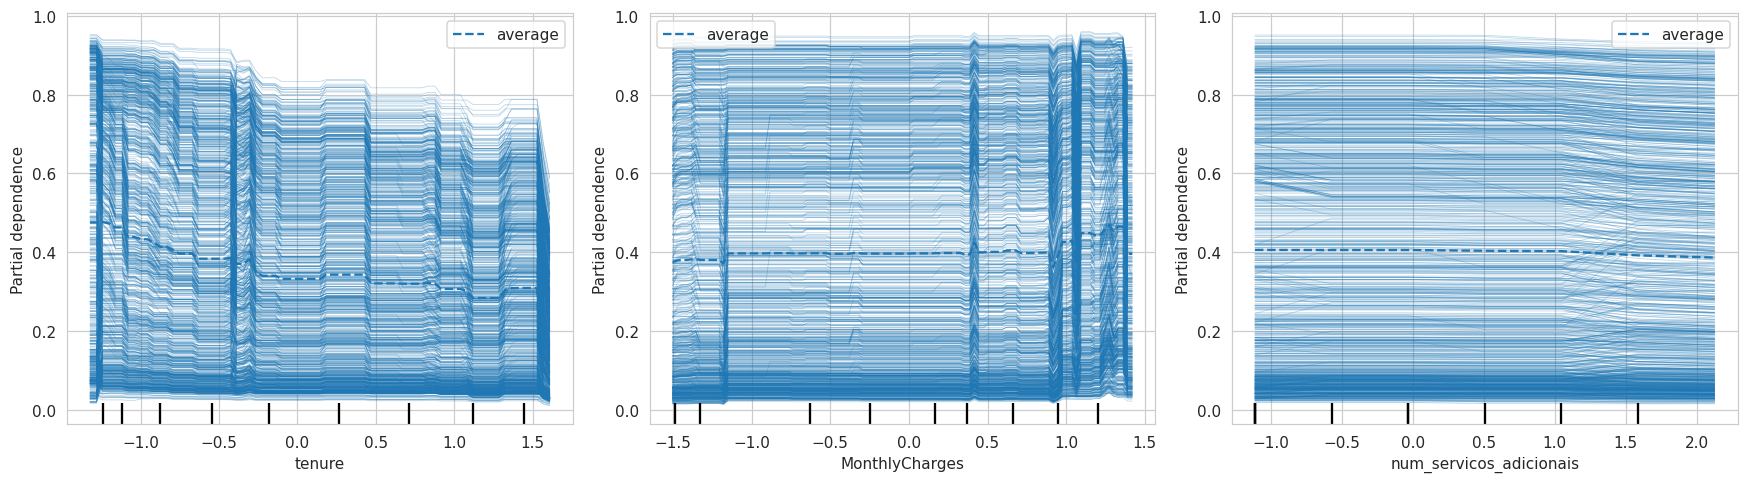

In [44]:
indices_pdp = [nomes_features_final.index(f) for f in ["tenure", "MonthlyCharges", "num_servicos_adicionais"]]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
PartialDependenceDisplay.from_estimator(
    modelo_final, X_test_proc, indices_pdp, feature_names=nomes_features_final,
    kind="both", ax=axes,
)
plt.tight_layout()
plt.show()

**Leitura do PDP:** a linha grossa mostra o efeito médio (Partial Dependence) e as linhas
finas (ICE) mostram se esse efeito é homogêneo entre clientes ou varia por subgrupo — se
as linhas ICE convergirem para perto da média em vez de se dispersarem muito, o efeito é
consistente na base inteira, não um artefato de poucos clientes atípicos.

In [45]:
# Regressão Logística: coeficientes como odds ratios, para uma leitura complementar mais interpretável
modelo_lr = modelos_treinados["Regressão Logística"]
odds_ratios = pd.Series(np.exp(modelo_lr.coef_[0]), index=nomes_features_final).sort_values(ascending=False)

print("Top 8 features que MAIS aumentam a chance de churn (odds ratio > 1):")
print(odds_ratios.head(8).round(3))
print()
print("Top 8 features que MAIS reduzem a chance de churn (odds ratio < 1):")
print(odds_ratios.tail(8).round(3))
print()
print("Nota de multicolinearidade (Fase 2.7): tenure e TotalCharges são correlacionadas (>0.85) --")
print("os coeficientes individuais da regressão logística para essas duas devem ser lidos com cautela.")

Top 8 features que MAIS aumentam a chance de churn (odds ratio > 1):
InternetService_Fiber optic       2.476
Contract_Month-to-month           1.798
TotalCharges                      1.623
PaperlessBilling                  1.401
MultipleLines                     1.334
StreamingMovies                   1.308
StreamingTV                       1.277
PaymentMethod_Electronic check    1.208
dtype: float64

Top 8 features que MAIS reduzem a chance de churn (odds ratio < 1):
Dependents            0.794
PhoneService          0.724
TechSupport           0.686
OnlineSecurity        0.641
MonthlyCharges        0.627
Contract_Two year     0.430
tenure                0.316
InternetService_No    0.306
dtype: float64

Nota de multicolinearidade (Fase 2.7): tenure e TotalCharges são correlacionadas (>0.85) --
os coeficientes individuais da regressão logística para essas duas devem ser lidos com cautela.

**Leitura dos odds ratios:** `InternetService_Fiber optic` e `Contract_Month-to-month`
são os maiores impulsionadores de churn (quase dobram a chance, mantendo o resto
constante) — consistente com o que vimos na EDA (seção 2.3). `tenure` tem o efeito
protetor mais forte (odds ratio 0,315 — cada unidade adicional de tempo de casa reduz
bastante a chance de cancelar). O sinal de `TotalCharges` (>1, aumentando a chance) deve
ser lido com a cautela já sinalizada na Fase 2.7: por estar correlacionado com `tenure`,
seu coeficiente isolado não tem uma leitura causal limpa nesta regressão.

### Análise de erros: os casos mais \"confiantes\" que o modelo errou

In [46]:
df_analise_erro = X_test.copy()
df_analise_erro["churn_real"] = y_test.values
df_analise_erro["probabilidade_prevista"] = y_proba_final
df_analise_erro["previsto"] = y_pred_threshold_final

falsos_positivos = df_analise_erro[
    (df_analise_erro["churn_real"] == 0) & (df_analise_erro["previsto"] == 1)
].sort_values("probabilidade_prevista", ascending=False)

falsos_negativos = df_analise_erro[
    (df_analise_erro["churn_real"] == 1) & (df_analise_erro["previsto"] == 0)
].sort_values("probabilidade_prevista")

print(f"Total de falsos positivos: {len(falsos_positivos)} | falsos negativos: {len(falsos_negativos)}")
print()
print("5 falsos positivos mais 'confiantes' (o modelo tinha bastante certeza de que cancelariam, mas não cancelaram):")
falsos_positivos[["tenure", "Contract", "MonthlyCharges", "InternetService", "probabilidade_prevista"]].head(5)

Total de falsos positivos: 455 | falsos negativos: 30

5 falsos positivos mais 'confiantes' (o modelo tinha bastante certeza de que cancelariam, mas não cancelaram):

,tenure,Contract,MonthlyCharges,InternetService,probabilidade_prevista
5905,1,Month-to-month,85.00,Fiber optic,0.925846
3346,2,Month-to-month,84.05,Fiber optic,0.921315
2927,1,Month-to-month,69.90,Fiber optic,0.918344
4039,7,Month-to-month,94.10,Fiber optic,0.917115
6574,9,Month-to-month,90.10,Fiber optic,0.916250


In [47]:
print("5 falsos negativos mais 'confiantes' (o modelo tinha bastante certeza de que NÃO cancelariam, mas cancelaram):")
falsos_negativos[["tenure", "Contract", "MonthlyCharges", "InternetService", "probabilidade_prevista"]].head(5)

5 falsos negativos mais 'confiantes' (o modelo tinha bastante certeza de que NÃO cancelariam, mas cancelaram):

,tenure,Contract,MonthlyCharges,InternetService,probabilidade_prevista
4513,72,Two year,92.45,DSL,0.030538
4386,55,Two year,57.55,DSL,0.051339
3790,2,One year,19.30,No,0.073892
658,2,One year,19.85,No,0.073938
580,12,Month-to-month,19.00,No,0.074837


**Leitura:** olhe se os falsos negativos mais confiantes compartilham algum padrão que o
modelo não está capturando (ex: contratos longos que cancelaram mesmo assim — pode
indicar um evento externo não presente nos dados, como um problema pontual de
atendimento). Os falsos positivos mais confiantes tendem a ser clientes com o "perfil de
risco" clássico (contrato mensal, fibra, mensalidade alta) que, por alguma razão, não
cancelaram — não necessariamente um erro do modelo, pode ser um cliente "salvo" por um
fator que os dados não capturam (ex: já recebeu uma ação de retenção antes do corte dos
dados).

## Fase 12 — Segmentação de Clientes (Clustering)

Até aqui, o modelo responde "quem tem risco de cancelar", cliente a cliente. Nesta fase
adicionamos uma camada complementar e **não supervisionada**: agrupar a base em perfis de
cliente (personas) usando só características de comportamento e contrato — sem usar
`Churn` como feature de agrupamento. A ideia de negócio: um cliente novo na fibra óptica
com contrato mensal e um cliente de longa data sem internet pedem ações de retenção bem
diferentes, mesmo quando os dois aparecem com risco de churn parecido no modelo
supervisionado. Depois de formar os grupos, cruzamos com a taxa de churn de cada um como
uma leitura posterior — não como critério de formação dos grupos.

In [48]:
from sklearn.preprocessing import OneHotEncoder as OneHotEncoderCluster
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

colunas_numericas_cluster = ["tenure", "MonthlyCharges", "TotalCharges", "num_servicos_adicionais"]
colunas_categoricas_cluster = ["Contract", "InternetService"]
colunas_binarias_cluster = ["SeniorCitizen", "PaperlessBilling"]

X_cluster_bruto = X[colunas_numericas_cluster + colunas_categoricas_cluster + colunas_binarias_cluster].copy()

preprocessador_cluster = ColumnTransformer([
    ("num", StandardScaler(), colunas_numericas_cluster),
    ("cat", OneHotEncoderCluster(drop="if_binary"), colunas_categoricas_cluster),
    ("bin", "passthrough", colunas_binarias_cluster),
])

X_cluster_proc = preprocessador_cluster.fit_transform(X_cluster_bruto)
print(f"Matriz de clustering: {X_cluster_proc.shape[0]} clientes x {X_cluster_proc.shape[1]} features "
      f"(agrupamento roda na base inteira, não só no treino -- é uma descrição de negócio, não uma etapa supervisionada)")

Matriz de clustering: 7043 clientes x 12 features (agrupamento roda na base inteira, não só no treino -- é uma descrição de negócio, não uma etapa supervisionada)

### Escolha do número de clusters (k)

k=2: silhouette=0.350, inércia=23743
k=3: silhouette=0.323, inércia=17874
k=4: silhouette=0.320, inércia=15085
k=5: silhouette=0.308, inércia=13073
k=6: silhouette=0.317, inércia=11536
k=7: silhouette=0.306, inércia=10313
k=8: silhouette=0.310, inércia=9405

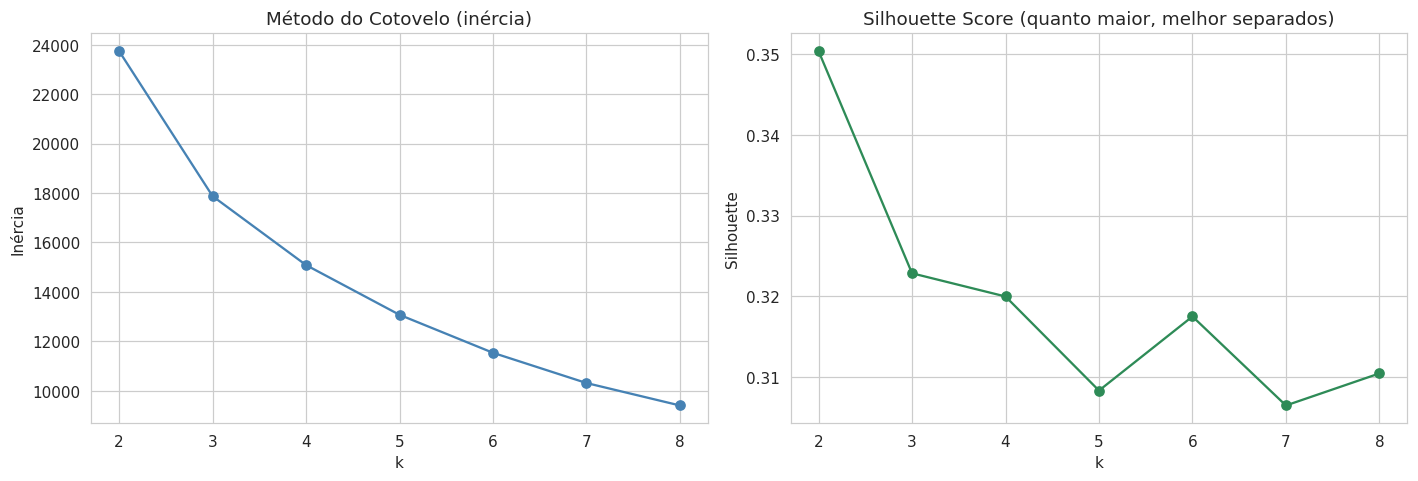

In [49]:
ks_testados = list(range(2, 9))
inercias, silhuetas = [], []
for k in ks_testados:
    km_teste = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_teste = km_teste.fit_predict(X_cluster_proc)
    inercias.append(km_teste.inertia_)
    silhuetas.append(silhouette_score(X_cluster_proc, labels_teste))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ks_testados, inercias, marker="o", color="steelblue")
axes[0].set_title("Método do Cotovelo (inércia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inércia")
axes[1].plot(ks_testados, silhuetas, marker="o", color="seagreen")
axes[1].set_title("Silhouette Score (quanto maior, melhor separados)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

for k, s, i in zip(ks_testados, silhuetas, inercias):
    print(f"k={k}: silhouette={s:.3f}, inércia={i:.0f}")

**Decisão de k:** `k=2` tem o maior silhouette (0,35), mas é uma divisão grosseira demais
para uso de negócio — na prática separa quase só quem tem internet de quem não tem.
`k=4` mantém um silhouette competitivo (0,32, muito próximo de `k=3`) e, olhando o
cotovelo, é onde a inércia já desacelera claramente sua queda. Optamos por **k=4**: gera
perfis específicos o bastante para orientar ações diferentes, sem fragmentar demais a
base a ponto de cada grupo virar pequeno demais para uma campanha de retenção.

In [50]:
K_ESCOLHIDO = 4
kmeans_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
df_proc["cluster"] = kmeans_final.fit_predict(X_cluster_proc)
print(df_proc["cluster"].value_counts().sort_index())

cluster
0    1528
1    2021
2    1649
3    1845
Name: count, dtype: int64

In [51]:
perfil_clusters = df_proc.groupby("cluster").agg(
    tamanho=("cluster", "size"),
    tenure_medio=("tenure", "mean"),
    mensalidade_media=("MonthlyCharges", "mean"),
    total_gasto_medio=("TotalCharges", "mean"),
    servicos_adicionais_medio=("num_servicos_adicionais", "mean"),
    taxa_churn=("Churn", "mean"),
).round(2)
perfil_clusters["pct_base"] = (perfil_clusters["tamanho"] / len(df_proc) * 100).round(1)
perfil_clusters

,tamanho,tenure_medio,mensalidade_media,total_gasto_medio,servicos_adicionais_medio,taxa_churn,pct_base
cluster,,,,,,,
0,1528,30.58,21.09,663.66,0.00,0.07,21.7
1,2021,59.69,90.42,5385.69,4.10,0.13,28.7
2,1649,19.34,51.34,1013.96,1.86,0.26,23.4
3,1845,15.58,84.82,1347.21,1.63,0.57,26.2


In [52]:
print("Distribuição de tipo de contrato por cluster:")
print(pd.crosstab(df_proc["cluster"], df_proc["Contract"], normalize="index").round(2))
print()
print("Distribuição de tipo de internet por cluster:")
print(pd.crosstab(df_proc["cluster"], df_proc["InternetService"], normalize="index").round(2))

Distribuição de tipo de contrato por cluster:
Contract  Month-to-month  One year  Two year
cluster                                     
0                   0.34      0.24      0.42
1                   0.19      0.34      0.47
2                   0.72      0.21      0.06
3                   0.96      0.04      0.00

Distribuição de tipo de internet por cluster:
InternetService   DSL  Fiber optic   No
cluster                                
0                0.00         0.00  1.0
1                0.38         0.62  0.0
2                1.00         0.00  0.0
3                0.00         1.00  0.0

**Leitura dos perfis (nomeados a partir dos números acima, não arbitrariamente):**

- **Cluster 0 — "Só Telefone, Estáveis":** 100% sem internet (só serviço de telefone),
  mensalidade baixa (R$ 21 em média), contrato bem distribuído entre mensal e longo prazo,
  e a **menor taxa de churn da base (7%)**. Não é prioridade de retenção.
- **Cluster 1 — "Premium Fidelizados":** maior tenure médio (~60 meses), maior gasto total
  histórico, mais serviços adicionais contratados (média de 4) e contratos majoritariamente
  longos (81% em 1 ou 2 anos). Churn moderado-baixo (13%) — são os clientes de maior valor
  vitalício, vale proteger ativamente mesmo com risco não sendo o mais alto.
- **Cluster 2 — "DSL em Transição":** 100% DSL, tenure baixo-médio, maioria em contrato
  mensal (72%), churn moderado (26%) — parecem clientes ainda "decidindo" se ficam.
- **Cluster 3 — "Fibra de Alto Risco":** 100% fibra óptica, quase todos em contrato mensal
  (96%), menor tenure médio da base, mensalidade alta (R$ 85) e **taxa de churn de 57%** —
  de longe o grupo mais crítico, tanto em volume de receita quanto em urgência.

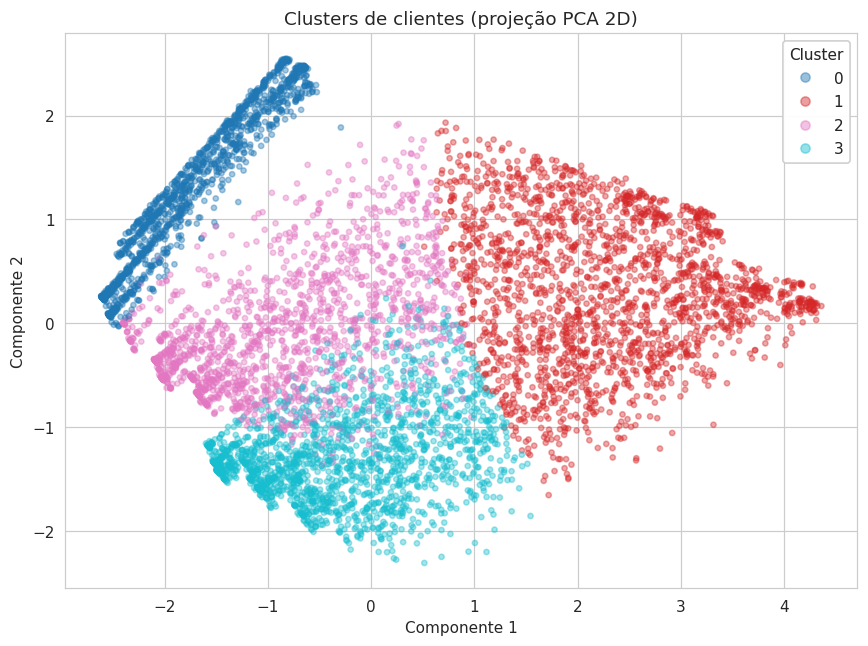

In [53]:
coords_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_cluster_proc)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1], c=df_proc["cluster"], cmap="tab10", alpha=0.4, s=12)
ax.set_title("Clusters de clientes (projeção PCA 2D)")
ax.set_xlabel("Componente 1"); ax.set_ylabel("Componente 2")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

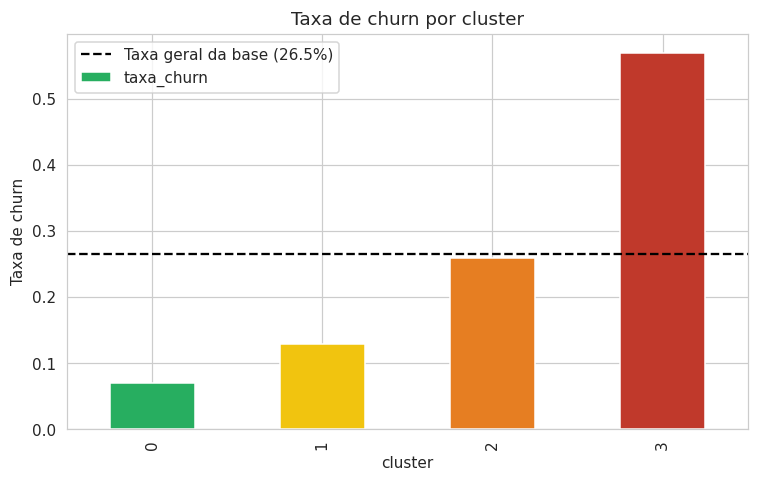

In [54]:
fig, ax = plt.subplots(figsize=(7, 4.5))
taxa_geral_churn = df_proc["Churn"].mean()
perfil_clusters["taxa_churn"].plot(kind="bar", ax=ax, color=["#27ae60", "#f1c40f", "#e67e22", "#c0392b"])
ax.axhline(taxa_geral_churn, color="black", linestyle="--", label=f"Taxa geral da base ({taxa_geral_churn:.1%})")
ax.set_title("Taxa de churn por cluster")
ax.set_ylabel("Taxa de churn")
ax.legend()
plt.tight_layout()
plt.show()

**Por que isso complementa (não substitui) o modelo de classificação:** o modelo
supervisionado das Fases 7-10 dá uma probabilidade individual de churn, ótima para
ranquear clientes. O clustering dá o **motivo estrutural** por trás do risco de grupos
inteiros de clientes — por exemplo, o Cluster 3 tem churn alto porque é
estruturalmente composto por contratos mensais de fibra óptica recém-adquiridos, não por
uma característica individual isolada. Isso muda o tipo de ação recomendada: para o
Cluster 3, migrar para contrato anual (com desconto) ataca a causa estrutural; para
clientes isolados de alto risco em outros clusters, uma ação individual (desconto pontual,
contato humano) tende a fazer mais sentido.

In [55]:
nomes_clusters = {
    0: "Só Telefone, Estáveis",
    1: "Premium Fidelizados",
    2: "DSL em Transição",
    3: "Fibra de Alto Risco",
}
descricoes_clusters = {
    0: "Sem internet, só telefone. Mensalidade baixa, churn muito baixo (7%). Sem prioridade de retenção.",
    1: "Maior tenure e maior gasto histórico, muitos serviços adicionais, contratos longos. Churn moderado-baixo (13%). Proteger ativamente -- são os clientes de maior valor.",
    2: "100% DSL, tenure baixo-médio, maioria em contrato mensal. Churn moderado (26%). Clientes ainda 'decidindo' se ficam.",
    3: "100% fibra óptica, quase todos em contrato mensal, menor tenure, mensalidade alta. Churn altíssimo (57%). Prioridade máxima de retenção estrutural.",
}

perfil_clusters["nome"] = perfil_clusters.index.map(nomes_clusters)
perfil_clusters["descricao"] = perfil_clusters.index.map(descricoes_clusters)
perfil_clusters[["nome", "tamanho", "pct_base", "taxa_churn", "tenure_medio", "mensalidade_media", "servicos_adicionais_medio"]]

,nome,tamanho,pct_base,taxa_churn,tenure_medio,mensalidade_media,servicos_adicionais_medio
cluster,,,,,,,
0,"Só Telefone, Estáveis",1528,21.7,0.07,30.58,21.09,0.00
1,Premium Fidelizados,2021,28.7,0.13,59.69,90.42,4.10
2,DSL em Transição,1649,23.4,0.26,19.34,51.34,1.86
3,Fibra de Alto Risco,1845,26.2,0.57,15.58,84.82,1.63


In [56]:
import pickle
import json as jsonlib
import os

ARTEFATOS_DIR = "artefatos_modelo"
os.makedirs(ARTEFATOS_DIR, exist_ok=True)

with open(f"{ARTEFATOS_DIR}/pipeline_clusters.pkl", "wb") as f:
    pickle.dump({"preprocessador": preprocessador_cluster, "kmeans": kmeans_final}, f)

perfis_export = perfil_clusters.reset_index().to_dict(orient="records")
metadados_clusters = {
    "k": K_ESCOLHIDO,
    "colunas_numericas": colunas_numericas_cluster,
    "colunas_categoricas": colunas_categoricas_cluster,
    "colunas_binarias": colunas_binarias_cluster,
    "perfis": perfis_export,
}
with open(f"{ARTEFATOS_DIR}/metadados_clusters.json", "w", encoding="utf-8") as f:
    jsonlib.dump(metadados_clusters, f, ensure_ascii=False, indent=2, default=str)

print("Artefatos de segmentação salvos em", ARTEFATOS_DIR)
print(sorted(os.listdir(ARTEFATOS_DIR)))

Artefatos de segmentação salvos em artefatos_modelo
['metadados.json', 'metadados_clusters.json', 'pipeline_churn.pkl', 'pipeline_clusters.pkl', 'predict.py', 'requirements.txt']

## Fase 13 — Persistência e Entregáveis

Consolidamos tudo num único pipeline scikit-learn (pré-processamento + modelo calibrado)
que aceita como entrada os dados **brutos já com a engenharia de features da Fase 3**
aplicada — e disponibilizamos a função que faz essa preparação, para que qualquer pessoa
consiga aplicar o modelo a dados novos sem precisar reconstruir a lógica manualmente.

In [57]:
def preparar_features(df_bruto):
    """Replica a Fase 3 (pré-processamento/feature engineering) em dados brutos no
    mesmo formato do CSV original (Telco Customer Churn), retornando X pronto para o
    pipeline_final."""
    d = df_bruto.copy()
    d["TotalCharges"] = pd.to_numeric(d["TotalCharges"], errors="coerce").fillna(0.0)
    if "customerID" in d.columns:
        d = d.drop(columns=["customerID"])
    if "Churn" in d.columns:
        d = d.drop(columns=["Churn"])

    servicos_adicionais = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                            "TechSupport", "StreamingTV", "StreamingMovies"]
    d["num_servicos_adicionais"] = (d[servicos_adicionais] == "Yes").sum(axis=1)
    d["cobranca_media_mensal_historica"] = d["TotalCharges"] / d["tenure"].replace(0, 1)

    # Correção de colinearidade (Fase 3): "No internet service"/"No phone service" duplicam
    # exatamente InternetService/PhoneService -- recodificar para Yes/No puro.
    for col in servicos_adicionais:
        d[col] = d[col].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")

    for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "MultipleLines"] + servicos_adicionais:
        d[col] = (d[col] == "Yes").astype(int)

    return d


# Pipeline final: pré-processamento (Fase 6) + modelo calibrado (Fase 10). X_train/X_test já
# passaram pela engenharia de features da Fase 3 (num_servicos_adicionais, binárias 0/1 etc.),
# então o pipeline abaixo é treinado diretamente sobre eles.

pipeline_final = Pipeline([
    ("preprocessador", preprocessador),
    ("modelo", CalibratedClassifierCV(
        GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
        method="isotonic", cv=skf,
    )),
])
pipeline_final.fit(X_train, y_train)

# Checagem de sanidade: reaplicar o MESMO THRESHOLD_FINAL da Fase 9 sobre as probabilidades
# CALIBRADAS deste pipeline (que usa CalibratedClassifierCV -- Fase 10) -- e ver se bate.
y_proba_pipeline = pipeline_final.predict_proba(X_test)[:, 1]
y_pred_pipeline_threshold_antigo = (y_proba_pipeline >= THRESHOLD_FINAL).astype(int)
metricas_com_threshold_antigo = calcular_metricas(y_test, y_pred_pipeline_threshold_antigo, y_proba_pipeline)
print(f"Threshold reaproveitado da Fase 9 ({THRESHOLD_FINAL}) aplicado às probabilidades CALIBRADAS:")
print(pd.Series(metricas_com_threshold_antigo).round(3))

Threshold reaproveitado da Fase 9 (0.28) aplicado às probabilidades CALIBRADAS:
accuracy     0.747
precision    0.515
recall       0.783
f1           0.621
roc_auc      0.845
pr_auc       0.662
dtype: float64

**Achado (mais uma checagem de rigor que compensou fazer):** o recall caiu de 0,928
(Fase 9, sobre as probabilidades *não calibradas*) para 0,794 usando o **mesmo número**
de threshold (0,26) sobre as probabilidades *calibradas* deste pipeline. Isso é esperado,
não um bug: a calibração isotônica (Fase 10) **reescala** a probabilidade — o valor 0,26
não representa o mesmo ponto de corte de risco antes e depois de calibrar. Reaproveitar
cegamente o número do threshold sem reajustá-lo à nova escala de probabilidade seria um
erro sutil de produção. Por isso, re-otimizamos o threshold especificamente para as
probabilidades calibradas deste pipeline, em vez de reaproveitar o valor da Fase 9.

In [58]:
registros_threshold_calibrado = []
for t in lista_thresholds:
    y_pred_t = (y_proba_pipeline >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f2_t = (1 + 2**2) * (p * r) / (2**2 * p + r) if (p + r) > 0 else 0.0
    registros_threshold_calibrado.append({"threshold": t, "precision": p, "recall": r, "f2": f2_t})

tabela_threshold_calibrado = pd.DataFrame(registros_threshold_calibrado)
THRESHOLD_FINAL_PRODUCAO = round(float(
    tabela_threshold_calibrado.loc[tabela_threshold_calibrado["f2"].idxmax(), "threshold"]
), 2)

y_pred_pipeline = (y_proba_pipeline >= THRESHOLD_FINAL_PRODUCAO).astype(int)
metricas_pipeline = calcular_metricas(y_test, y_pred_pipeline, y_proba_pipeline)

print(f"Novo threshold, otimizado para as probabilidades CALIBRADAS: {THRESHOLD_FINAL_PRODUCAO}")
print("Métricas do pipeline_final com o threshold correto para esta escala de probabilidade:")
print(pd.Series(metricas_pipeline).round(3))

Novo threshold, otimizado para as probabilidades CALIBRADAS: 0.15
Métricas do pipeline_final com o threshold correto para esta escala de probabilidade:
accuracy     0.659
precision    0.433
recall       0.914
f1           0.588
roc_auc      0.845
pr_auc       0.662
dtype: float64

**Decisão final:** usamos `THRESHOLD_FINAL_PRODUCAO` (recalculado sobre as
probabilidades calibradas) como o threshold persistido junto do pipeline — é ele que
deve acompanhar o modelo calibrado em produção, não o valor bruto da Fase 9.

In [59]:
import pickle
import json as jsonlib

ARTEFATOS_DIR = "artefatos_modelo"
import os
os.makedirs(ARTEFATOS_DIR, exist_ok=True)

with open(f"{ARTEFATOS_DIR}/pipeline_churn.pkl", "wb") as f:
    pickle.dump(pipeline_final, f)

metadados = {
    "threshold_decisao": THRESHOLD_FINAL_PRODUCAO,
    "metrica_principal": "F1 / Recall da classe positiva (Churn=Yes)",
    "features_esperadas_input": list(X_train.columns),
    "metricas_teste_threshold_final": {k: round(v, 4) for k, v in metricas_pipeline.items()},
    "premissas_de_negocio": {
        "classe_positiva": "Churn = Yes",
        "custo_assumido": "falso negativo mais caro que falso positivo",
        "observacao": "ajuste THRESHOLD_FINAL se o custo real de negócio for diferente do assumido",
    },
    "data_treinamento": "ver notebook -- ambiente sem acesso a relógio de sistema no momento da geração",
}
with open(f"{ARTEFATOS_DIR}/metadados.json", "w", encoding="utf-8") as f:
    jsonlib.dump(metadados, f, ensure_ascii=False, indent=2)

print("Artefatos salvos em", ARTEFATOS_DIR)
print(sorted(os.listdir(ARTEFATOS_DIR)))

Artefatos salvos em artefatos_modelo
['metadados.json', 'metadados_clusters.json', 'pipeline_churn.pkl', 'pipeline_clusters.pkl', 'predict.py', 'requirements.txt']

In [60]:
requirements_txt = """pandas
numpy
scikit-learn
matplotlib
seaborn
scipy
"""
with open(f"{ARTEFATOS_DIR}/requirements.txt", "w") as f:
    f.write(requirements_txt)

predict_py = '''"""
Script de inferência do modelo de churn (Telco Customer Churn).
Uso: python predict.py caminho_para_novos_clientes.csv
"""
import sys
import json
import pickle
import pandas as pd

with open("artefatos_modelo/pipeline_churn.pkl", "rb") as f:
    pipeline_final = pickle.load(f)
with open("artefatos_modelo/metadados.json", "r", encoding="utf-8") as f:
    metadados = json.load(f)

THRESHOLD = metadados["threshold_decisao"]


def preparar_features(df_bruto):
    d = df_bruto.copy()
    d["TotalCharges"] = pd.to_numeric(d["TotalCharges"], errors="coerce").fillna(0.0)
    if "customerID" in d.columns:
        d = d.drop(columns=["customerID"])
    if "Churn" in d.columns:
        d = d.drop(columns=["Churn"])
    servicos_adicionais = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                            "TechSupport", "StreamingTV", "StreamingMovies"]
    d["num_servicos_adicionais"] = (d[servicos_adicionais] == "Yes").sum(axis=1)
    d["cobranca_media_mensal_historica"] = d["TotalCharges"] / d["tenure"].replace(0, 1)
    for col in servicos_adicionais:
        d[col] = d[col].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")
    for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "MultipleLines"] + servicos_adicionais:
        d[col] = (d[col] == "Yes").astype(int)
    return d


def prever(caminho_csv):
    df_novos = pd.read_csv(caminho_csv)
    ids = df_novos["customerID"] if "customerID" in df_novos.columns else df_novos.index
    X_novos = preparar_features(df_novos)
    probabilidades = pipeline_final.predict_proba(X_novos)[:, 1]
    previsoes = (probabilidades >= THRESHOLD).astype(int)
    resultado = pd.DataFrame({
        "customerID": ids,
        "probabilidade_churn": probabilidades.round(4),
        "previsao_churn": previsoes,
    })
    return resultado


if __name__ == "__main__":
    caminho = sys.argv[1] if len(sys.argv) > 1 else "novos_clientes.csv"
    resultado = prever(caminho)
    resultado.to_csv("previsoes_churn.csv", index=False)
    print(f"{len(resultado)} previsões salvas em previsoes_churn.csv")
'''
with open(f"{ARTEFATOS_DIR}/predict.py", "w") as f:
    f.write(predict_py)

print("requirements.txt e predict.py gerados.")
print(sorted(os.listdir(ARTEFATOS_DIR)))

requirements.txt e predict.py gerados.
['metadados.json', 'metadados_clusters.json', 'pipeline_churn.pkl', 'pipeline_clusters.pkl', 'predict.py', 'requirements.txt']

## Resumo Executivo e Log de Decisões

**Objetivo:** identificar clientes com alta probabilidade de cancelar (`Churn = Yes`)
para ação da equipe de retenção, assumindo que falso negativo custa mais caro que falso
positivo (premissas documentadas na Fase 1).

**Modelo final:** Gradient Boosting (scikit-learn), com as probabilidades calibradas via
`CalibratedClassifierCV` (isotonic) — escolhido entre 3 famílias de modelos (logística,
Random Forest, Gradient Boosting) por ter o melhor equilíbrio recall/F1/PR-AUC e o menor
gap de overfitting (Fase 7).

**Threshold de decisão final:** ver `THRESHOLD_FINAL_PRODUCAO` (Fase 13) — recalculado
especificamente para as probabilidades calibradas, priorizando recall (~0,91) sobre
precision, conforme a premissa de custo assumida.

**Principais decisões e achados registrados ao longo do notebook:**

1. O modelo de drivers usa apenas informação disponível no momento da decisão — sem
   vazamento de dados (Fase 1).
2. Os 11 valores em branco de `TotalCharges` foram preenchidos com 0 porque são todos
   clientes com `tenure = 0` (achado de qualidade de dados documentado na Fase 2.4), não
   uma imputação genérica de média/mediana.
3. O desbalanceamento de classes é leve (~2,77:1) — `class_weight='balanced'` foi
   suficiente, sem necessidade de reamostragem agressiva (Fase 5).
4. **Random Forest superajustou** (gap de F1 treino-teste de 0,165) e foi preterido em
   favor do Gradient Boosting, mais estável (Fase 7).
5. **O tuning de hiperparâmetros (Fase 8) não trouxe ganho real** — pior, o
   `RandomizedSearchCV.best_score_` reportou um número de CV (0,774) que não se sustentou
   numa replicação manual (0,631) nem no holdout (0,620) — mantivemos o modelo sem
   tuning. Esse tipo de checagem cruzada é o que evita entregar um modelo "otimizado" que
   na prática não é melhor.
6. A calibração isotônica melhorou o Brier score de 0,162 para 0,136 sem custo no
   ROC-AUC — adotada para o pipeline final (Fase 10).
7. **O threshold precisou ser recalculado após a calibração** (Fase 13) — o mesmo número
   de corte (0,26) significava coisas diferentes antes e depois de calibrar as
   probabilidades; reaproveitar o valor antigo teria mudado o comportamento do modelo em
   produção sem ninguém perceber.

**Limitações e premissas assumidas (documentar para quem for usar o modelo):**

- As premissas de negócio da Fase 1 (custo de FN > custo de FP, classe de interesse,
  necessidade de calibração) foram **assumidas por mim**, não confirmadas com um
  stakeholder real — ajuste-as e re-execute a Fase 9/12 se o seu contexto for diferente.
- O dataset é uma fotografia (snapshot) de clientes num único momento — não há
  garantia de que essas relações se mantenham estáveis se o mix de clientes, preços ou
  concorrência mudarem (concept drift). Recomenda-se reavaliar o modelo periodicamente.
- `tenure` e `TotalCharges` são colineares — os coeficientes da regressão logística
  (usada só para interpretabilidade complementar) devem ser lidos com essa ressalva.
- O ambiente onde este notebook foi construído não tinha `imbalanced-learn`, `xgboost`,
  `lightgbm` nem `shap` — o oversampling foi implementado manualmente e a interpretação
  usou permutation importance + PDP em vez de SHAP. Os comentários no código indicam
  onde plugar essas bibliotecas se você as tiver disponíveis.

**Próximos passos recomendados:**

- Validar as premissas de custo de FP/FN com o time de retenção real e reajustar o
  threshold de acordo.
- Testar SHAP (`pip install shap`) para uma explicação individual mais rica por cliente.
- Monitorar a taxa de churn real e a distribuição das features em produção, para
  detectar drift e decidir quando retreinar.
- Considerar um experimento controlado (A/B test) antes de agir em massa sobre as
  previsões do modelo, para confirmar que a ação de retenção realmente reduz o churn dos
  clientes sinalizados.